# Tennessee Eastman Process (TEP): Stage 2 - Domain Shift Diagnostics & Transferability Benchmark

This notebook establishes **Stage 2** of the research framework: a comprehensive empirical investigation of domain shift, feature space manifold structures, and transferability degradation across operational regimes in the **Tennessee Eastman Process (TEP)**.

### Objectives of Stage 2:
1. **Geometric Distance Quantization**: Measure distribution divergence between source and target process operating conditions using **Sliced Wasserstein Distance (SWD)**, **Maximum Mean Discrepancy (MMD)**, and **Fréchet Distance (FD)**.
2. **Global vs. Conditional Shift Breakdown**: Demonstrate empirically why evaluating distribution divergence conditionally on anomaly windows ($	ext{Anomaly}=1$) is essential for industrial failure detection.
3. **Supervised Transfer Benchmarking**: Quantify classification performance drop (**Transfer Penalty**) across **20 curated domain pairs** spanning similar mechanisms, same subsystem differences, unrelated mechanisms, and coherent/control multi-source groupings.
4. **Disturbance Mechanism Taxonomy**: Map 21 fault IDs into 6 physical disturbance mechanism classes to evaluate **Multiclass Fault Diagnosis** performance under operational domain shift.


## 1. Setup and Environment Configuration

This section initializes the Python execution environment, configures global random seeds (`SEED = 42`) for reproducibility across numerical computations, sets up PyTorch device execution (`CPU`/`GPU`), and resolves workspace directory paths for data loading and feature caching.


In [2]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

try:
    import pyreadr
except ImportError:
    pyreadr = None

from scipy.stats import wasserstein_distance
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import SVC, OneClassSVM
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import scipy.linalg
import matplotlib.cm as cm
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix



warnings.filterwarnings('ignore', category=UserWarning, module='sklearn.utils.parallel')
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

SEED = 42

def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)

set_seed(SEED)

current_dir = Path(os.getcwd())
if (current_dir / "data" / "Tennessee_Eastman_Process_Simulation_Dataset").exists():
    base_project_dir = current_dir
elif (current_dir.parent / "data" / "Tennessee_Eastman_Process_Simulation_Dataset").exists():
    base_project_dir = current_dir.parent
else:
    base_project_dir = current_dir

base_data_path = base_project_dir / "data" / "Tennessee_Eastman_Process_Simulation_Dataset" / "archive"
save_path      = base_project_dir / "data" / "Tennessee_Eastman_Process_Simulation_Dataset" / "processed_csv"
features_path  = base_project_dir / "data" / "Tennessee_Eastman_Process_Simulation_Dataset" / "features"

save_path.mkdir(parents=True, exist_ok=True)
features_path.mkdir(parents=True, exist_ok=True)

PAIR_CATEGORY_PALETTE = {
    "Similar mechanism": "#1b9e77",
    "Same subsystem, diff. type": "#d95f02",
    "Unrelated mechanism": "#7570b3",
    "Coherent group": "#66a61e",
    "Control group": "#e7298a",
}

MECHANISM_PALETTE = {
    0: "#2ca02c",  # Normal (Green)
    1: "#1f77b4",  # Step Disturbance (Blue)
    2: "#ff7f0e",  # Random Variation (Orange)
    3: "#d62728",  # Slow Dynamic Drift (Red)
    4: "#9467bd",  # Actuator Stiction (Purple)
    5: "#8c564b",  # Unknown Perturbation (Brown)
}

## 2. Data Loading & Feature Caching Protocol

In this section, raw TEP simulation data files (`.RData` or cached `.csv` files) are lazily loaded into memory. To optimize memory consumption and execution speed during iterative benchmarking, extracted window features are persisted to the `features/` directory as pre-processed CSV artifacts.


In [3]:
RAW_FILES = {
    "fault_free_train": "TEP_FaultFree_Training.RData",
    "fault_free_test":  "TEP_FaultFree_Testing.RData",
    "faulty_train":     "TEP_Faulty_Training.RData",
    "faulty_test":      "TEP_Faulty_Testing.RData",
}

df_header = pd.read_csv(save_path / "fault_free_train.csv", nrows=1)
SENSOR_COLUMNS = [c for c in df_header.columns if c not in ("faultNumber", "simulationRun", "sample")]

def load_raw_tep_data(raw_files: dict) -> dict:
    dfs = {}
    for key, filename in raw_files.items():
        csv_path = save_path / f"{key}.csv"
        if csv_path.exists():
            print(f"[cache] {key}: loading from {csv_path.name}")
            dfs[key] = pd.read_csv(csv_path, dtype=np.float32)
            continue
        rdata_path = base_data_path / filename
        if not rdata_path.exists():
            raise FileNotFoundError(f"Could not find {filename} in {base_data_path}.")
        print(f"[convert] {key}: reading {filename}")
        r_data = pyreadr.read_r(rdata_path)
        object_name = list(r_data.keys())[0]
        dfs[key] = r_data[object_name]
        dfs[key].to_csv(csv_path, index=False)
        print(f"[convert] {key}: cached to {csv_path.name}")
    return dfs

all_features_cached = all(
    (features_path / f"fault_{f_idx}_{sp}_w30_s20_sub1_r{r_num}.csv").exists()
    for f_idx in range(0, 21)
    for sp, r_num in [('train', 80), ('test', 100)]
)

if not all_features_cached:
    dfs = load_raw_tep_data(RAW_FILES)
    df_fault_free_train = dfs["fault_free_train"]
    df_fault_free_test  = dfs["fault_free_test"]
    df_faulty_train     = dfs["faulty_train"]
    df_faulty_test      = dfs["faulty_test"]
else:
    print("[cache] All 21 fault window feature CSVs found in features/. Skipping raw CSV memory load.")
    df_fault_free_train = pd.DataFrame()
    df_fault_free_test  = pd.DataFrame()
    df_faulty_train     = pd.DataFrame()
    df_faulty_test      = pd.DataFrame()

print(f"\nSensor/actuator variables: {len(SENSOR_COLUMNS)}")


[cache] All 21 fault window feature CSVs found in features/. Skipping raw CSV memory load.

Sensor/actuator variables: 52


## 3. Feature Engineering: Sliding-Window Statistical Descriptors

To capture temporal dynamics and multivariate process correlations, continuous time-series data from the 52 process variables are transformed using a sliding window approach.

- **Window Size**: `WINDOW_SIZE = 30` samples ($1.5 	ext{ hours}$ of process operation)
- **Window Step**: `STEP = 20` samples ($33.3\%$ window overlap)
- **Statistical Descriptors**: 4 rolling statistics per variable (`mean`, `std`, `min`, `max`), yielding a **208-dimensional feature vector** per window.
- **Transient Cutoff**: Samples prior to sample index 20 (`train`) and 160 (`test`) are dropped to eliminate non-stationary fault injection transients.


In [4]:
from pathlib import Path
import numpy as np
import pandas as pd

STAT_NAMES  = ['mean', 'std', 'min', 'max']
FEATURE_NAMES = [f'{v}_{s}' for v in SENSOR_COLUMNS for s in STAT_NAMES]

SUBSAMPLE   = 1
WINDOW_SIZE = 30
STEP        = 20  # 33.3% WINDOW OVERLAP (30 samples window, step 20)

MAX_RUNS_TRAIN = 80
MAX_RUNS_TEST  = 100

def extract_window_features(df_raw, split):
    if df_raw.empty:
        return np.array([]), np.array([])
    
    if 'simulationRun' in df_raw.columns:
        max_runs = MAX_RUNS_TRAIN if split == 'train' else MAX_RUNS_TEST
        available_runs = df_raw['simulationRun'].unique()
        selected_runs = available_runs[:max_runs]
        df_raw = df_raw[df_raw['simulationRun'].isin(selected_runs)].copy()

    inflection = 20 if split == 'train' else 160
    if 'sample' in df_raw.columns:
        df_raw = df_raw[df_raw['sample'] > inflection].copy()
        
    df_sub = df_raw.iloc[::SUBSAMPLE].copy()
    grouped = df_sub.groupby('simulationRun') if 'simulationRun' in df_sub.columns else [(None, df_sub)]
    
    feats, tgts = [], []
    for _, group in grouped:
        if len(group) < WINDOW_SIZE:
            continue
        fault_label = group['faultNumber'].iloc[0] if 'faultNumber' in group.columns else 0
        
        rolling = group[SENSOR_COLUMNS].rolling(window=WINDOW_SIZE)
        stat_frames = {
            'mean': rolling.mean(),
            'std':  rolling.std(),
            'min':  rolling.min(),
            'max':  rolling.max(),
        }
        for s in stat_frames:
            stat_frames[s] = stat_frames[s].iloc[WINDOW_SIZE - 1::STEP]
            
        run_stats = pd.DataFrame(
            {f'{col}_{s}': stat_frames[s][col] for s in STAT_NAMES for col in SENSOR_COLUMNS}
        ).dropna()
        
        if run_stats.empty:
            continue
        feats.append(run_stats.values)
        tgts.append(np.full(len(run_stats), fault_label))
        
    if not feats:
        return np.array([]), np.array([])
    return np.vstack(feats), np.concatenate(tgts)


def get_domain_features(fault_num, split):
    runs_tag = MAX_RUNS_TRAIN if split == 'train' else MAX_RUNS_TEST
    cache = features_path / f'fault_{fault_num}_{split}_w{WINDOW_SIZE}_s{STEP}_sub{SUBSAMPLE}_r{runs_tag}.csv'
    
    if cache.exists():
        df_c = pd.read_csv(cache)
        return df_c[FEATURE_NAMES].values, df_c['target'].values
        
    if fault_num == 0:
        df_src = df_fault_free_train if split == 'train' else df_fault_free_test
    elif split == 'train':
        df_src = df_faulty_train[df_faulty_train['faultNumber'] == fault_num]
    else:
        df_src = df_faulty_test[df_faulty_test['faultNumber'] == fault_num]
        
    X, y = extract_window_features(df_src, split)
    if len(X) == 0:
        return np.array([]), np.array([])
        
    df_out = pd.DataFrame(X, columns=FEATURE_NAMES)
    df_out['target'] = y
    df_out.to_csv(cache, index=False)
    return X, y


print("Pre-extracting / loading cached feature windows for all faults (WINDOW_SIZE=30, STEP=20).")
DOMAIN_FEATURES = {}
for fault_num in range(0, 21):
    DOMAIN_FEATURES[fault_num] = {}
    for split in ('train', 'test'):
        X, _ = get_domain_features(fault_num, split)
        DOMAIN_FEATURES[fault_num][split] = X

print(f"Loaded all 21 faults ({len(FEATURE_NAMES)} features). Train per fault: {len(DOMAIN_FEATURES[1]['train'])} windows, Test per fault: {len(DOMAIN_FEATURES[1]['test'])} windows.")


Pre-extracting / loading cached feature windows for all faults (WINDOW_SIZE=30, STEP=20).
Loaded all 21 faults (208 features). Train per fault: 1840 windows, Test per fault: 3900 windows.


## 4. Normal vs. Anomaly Domain DataFrame Construction

This section implements utility routines to extract and combine nominal steady-state data ($	ext{Fault } 0$) and specific fault-active data ($	ext{Fault } 1 \dots 20$) into structured DataFrames for supervised training and domain distance evaluations.


In [5]:
def build_domain_df(fault_ids: list[int], split: str = "train") -> pd.DataFrame:
    """Concatenate the shared fault-free pool (Anomaly=0) with the feature windows of
    one or more faults (Anomaly=1) into a single labelled DataFrame.
    """
    parts = []

    X0 = DOMAIN_FEATURES[0][split]
    if len(X0) > 0:
        df0 = pd.DataFrame(X0, columns=FEATURE_NAMES)
        df0["Anomaly"] = 0
        parts.append(df0)

    for f in fault_ids:
        Xf = DOMAIN_FEATURES[f][split]
        if len(Xf) == 0:
            continue
        dff = pd.DataFrame(Xf, columns=FEATURE_NAMES)
        dff["Anomaly"] = 1
        parts.append(dff)

    if not parts:
        return pd.DataFrame(columns=FEATURE_NAMES + ["Anomaly"])
    return pd.concat(parts, ignore_index=True)


## 5. Geometric Domain Distance Metrics: SWD, MMD, and Fréchet Distance

To quantify distribution shift between source and target operational domains, three complementary geometric distance metrics are computed on standardized feature spaces:

1. **Sliced Wasserstein Distance (SWD)**: Computes the 1D Optimal Transport distance averaged over $N_{	ext{projections}} = 50$ random unit direction vectors, capturing non-linear manifold geometry.
2. **Maximum Mean Discrepancy (MMD)**: Evaluates kernelized distribution distance using an RBF kernel ($\gamma = 1 / d$).
3. **Fréchet Distance (FD)**: Measures multivariate Gaussian distance between mean vectors and covariance matrices using matrix square root decomposition with numerical regularization.


In [6]:
def sliced_wasserstein(X: np.ndarray, Y: np.ndarray, n_projections: int = 50, random_state: int = 42) -> float:
    """Sliced Wasserstein Distance vectorized: mean 1D Wasserstein over random projections."""
    rng = np.random.default_rng(random_state)
    d = X.shape[1]
    projections = rng.standard_normal((n_projections, d))
    projections /= np.linalg.norm(projections, axis=1, keepdims=True)
    X_p = X @ projections.T
    Y_p = Y @ projections.T
    return float(np.mean([wasserstein_distance(X_p[:, i], Y_p[:, i]) for i in range(n_projections)]))


def mmd_rbf(X: np.ndarray, Y: np.ndarray) -> float:
    """MMD RBF con gamma standard di scikit-learn: 1 / n_features."""
    gamma = 1.0 / X.shape[1]
    XX = rbf_kernel(X, X, gamma)
    YY = rbf_kernel(Y, Y, gamma)
    XY = rbf_kernel(X, Y, gamma)
    return float(XX.mean() + YY.mean() - 2 * XY.mean())


def frechet_distance(X: np.ndarray, Y: np.ndarray, eps: float = 1e-3) -> float:
    """Frechet Distance between two multivariate Gaussians fitted to the data."""
    mu1, sigma1 = X.mean(axis=0), np.cov(X, rowvar=False) + eps * np.eye(X.shape[1])
    mu2, sigma2 = Y.mean(axis=0), np.cov(Y, rowvar=False) + eps * np.eye(X.shape[1])
    diff = mu1 - mu2
    covmean = np.real(scipy.linalg.sqrtm(sigma1.dot(sigma2)))
    return float(diff.dot(diff) + np.trace(sigma1) + np.trace(sigma2) - 2 * np.trace(covmean))


def compute_distances(X: np.ndarray, Y: np.ndarray, n_projections: int = 50, seed: int = SEED) -> dict:
    """Computes distance metrics between two feature sets using StandardScaler."""
    scaler = StandardScaler().fit(np.vstack([X, Y]))
    scaler.scale_ = np.maximum(scaler.scale_, 1e-3)
    Xs_sc = scaler.transform(X)
    Ys_sc = scaler.transform(Y)

    return {
        'SWD': sliced_wasserstein(Xs_sc, Ys_sc, n_projections=n_projections, random_state=seed),
        'MMD': mmd_rbf(Xs_sc, Ys_sc),
        'FD':  frechet_distance(Xs_sc, Ys_sc),
    }


def compute_conditional_distances(source_df: pd.DataFrame, target_df: pd.DataFrame,
                                  features, target_col: str = 'Anomaly') -> dict | None:
    """Filters fault-active windows (target_col==1) and delegates distance computation to compute_distances."""
    src_anom = source_df[source_df[target_col] == 1][features].values
    tgt_anom = target_df[target_df[target_col] == 1][features].values
    if len(src_anom) == 0 or len(tgt_anom) == 0:
        return None
    return compute_distances(src_anom, tgt_anom)


## 6. Fault Separability & Feature Space Manifold Analysis

In this section, we analyze the global separability of all 20 TEP fault types in the 208-dimensional feature space. By computing pairwise geometric distances across all fault combinations, we identify clusters of physically similar disturbance mechanisms versus decoupled plant dynamics.


In [7]:
faults_mapping = {
    0: "Normal (no fault)",
    1: "A/C feed ratio, B composition constant (Step)",
    2: "B composition, A/C ratio constant (Step)",
    3: "D feed temperature (Step)",
    4: "Reactor cooling water inlet temperature (Step)",
    5: "Condenser cooling water inlet temperature (Step)",
    6: "A feed loss (Step)",
    7: "C header pressure loss (Step)",
    8: "A, B, C feed composition (Random variation)",
    9: "D feed temperature (Random variation)",
    10: "C feed temperature (Random variation)",
    11: "Reactor cooling water inlet temperature (Random variation)",
    12: "Condenser cooling water inlet temperature (Random variation)",
    13: "Reaction kinetics (Slow drift)",
    14: "Reactor cooling water valve (Sticking)",
    15: "Condenser cooling water valve (Sticking)",
    16: "Unknown",
    17: "Unknown",
    18: "Unknown",
    19: "Unknown",
    20: "Unknown",
}



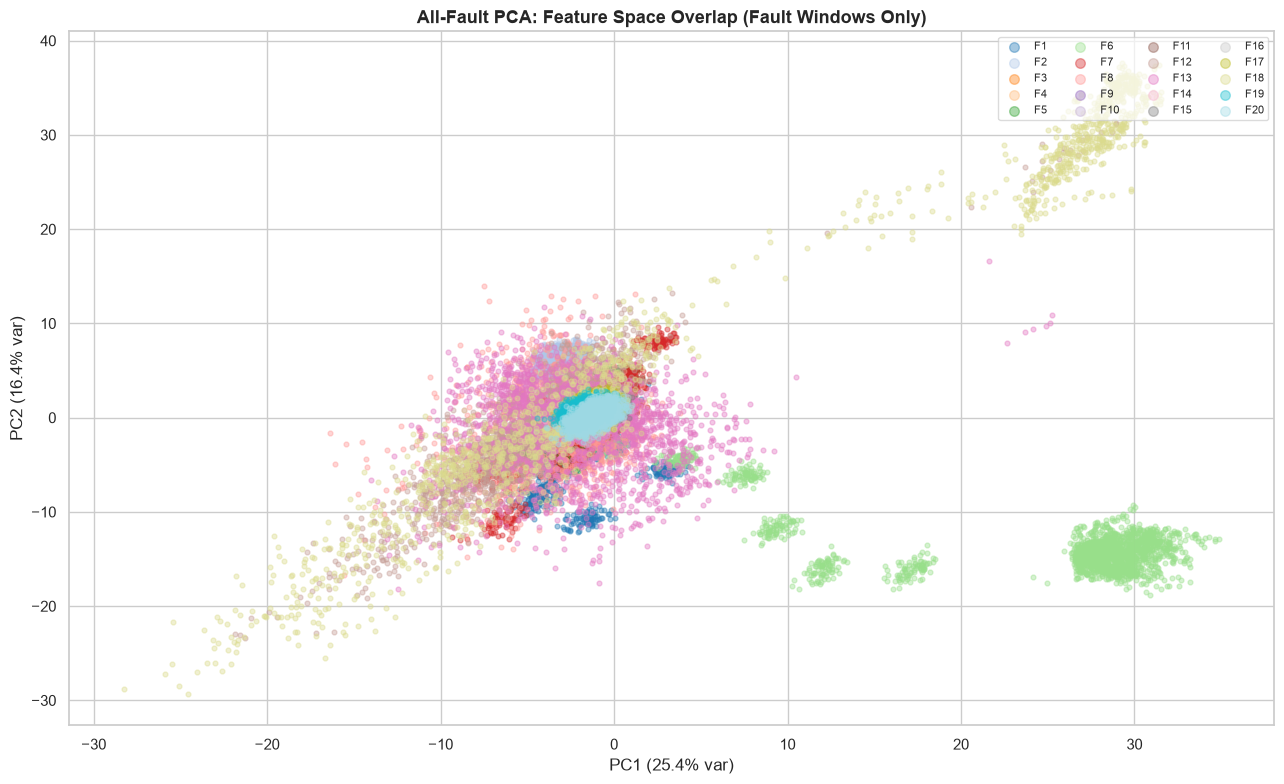

Variance explained by PC1+PC2: 41.8%


In [8]:
X_all, y_all = [], []
for f in range(1, 21):
    X_f = DOMAIN_FEATURES[f]['train']
    if len(X_f) == 0:
        continue
    X_all.append(X_f)
    y_all.extend([f] * len(X_f))

X_all = np.vstack(X_all)
y_all = np.array(y_all)

# PCA on fault windows only
scaler_pca = StandardScaler().fit(X_all)
X_scaled = scaler_pca.transform(X_all)
pca = PCA(n_components=2, random_state=SEED)
X_2d = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(13, 8))
colors = cm.tab20(np.linspace(0, 1, 20))

for fi, f in enumerate(range(1, 21)):
    mask = y_all == f
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=[colors[fi]], s=12, alpha=0.4, label=f'F{f}', rasterized=True)

ax.set_title('All-Fault PCA: Feature Space Overlap (Fault Windows Only)',
             fontweight='bold', fontsize=13)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.legend(ncol=4, fontsize=8, markerscale=2, loc='upper right', framealpha=0.7)
plt.tight_layout()
plt.show()

print(f"Variance explained by PC1+PC2: {sum(pca.explained_variance_ratio_[:2])*100:.1f}%")


20x20 inter-fault SWD matrix (subsampled to 1500 per fault)


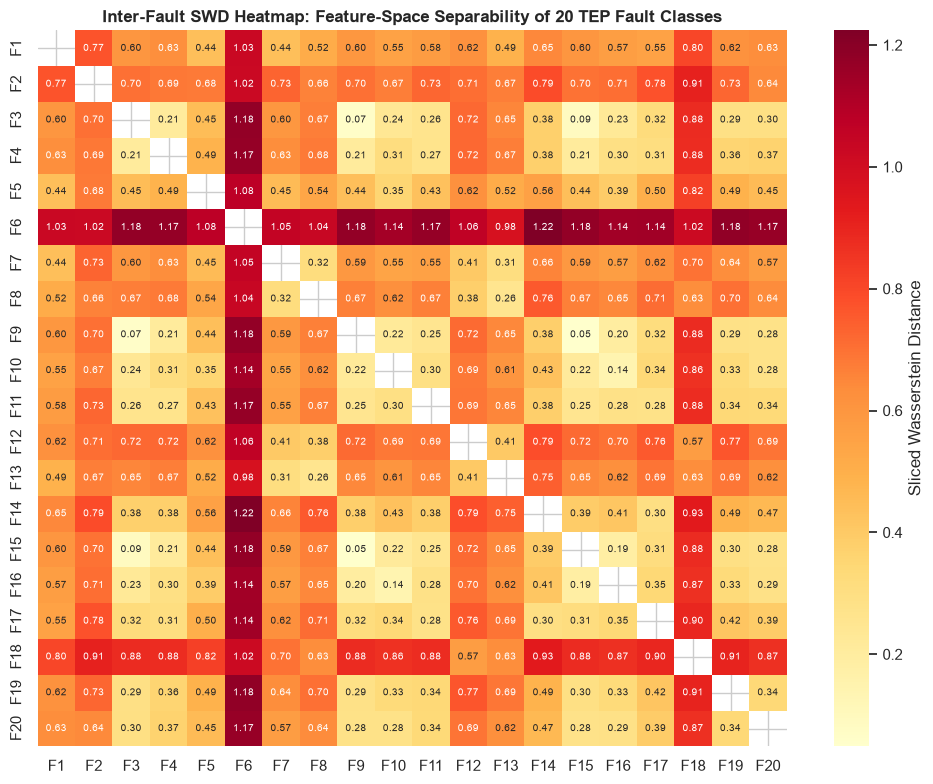


5 MOST SIMILAR fault pairs (hardest transfer):
  F9 <-> F15: SWD=0.0486
  F3 <-> F9: SWD=0.0668
  F3 <-> F15: SWD=0.0930
  F10 <-> F16: SWD=0.1413
  F15 <-> F16: SWD=0.1864

5 MOST DISSIMILAR fault pairs (easiest transfer):
  F6 <-> F14: SWD=1.2239
  F6 <-> F19: SWD=1.1783
  F3 <-> F6: SWD=1.1770
  F6 <-> F15: SWD=1.1761
  F6 <-> F9: SWD=1.1758


In [9]:
fault_ids = list(range(1, 21))
n = len(fault_ids)
swd_matrix = np.full((n, n), np.nan)

print("20x20 inter-fault SWD matrix (subsampled to 1500 per fault)")
for i, f1 in enumerate(fault_ids):
    for j, f2 in enumerate(fault_ids):
        if i == j:
            swd_matrix[i, j] = 0.0
        elif i < j:
            d = compute_distances(DOMAIN_FEATURES[f1]['train'], DOMAIN_FEATURES[f2]['train'])['SWD']
            swd_matrix[i, j] = d
            swd_matrix[j, i] = d  # symmetric

labels = [f'F{f}' for f in fault_ids]

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.eye(n, dtype=bool)
sns.heatmap(swd_matrix, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=labels, yticklabels=labels,
            mask=mask, ax=ax, annot_kws={'size': 7},
            cbar_kws={'label': 'Sliced Wasserstein Distance'})
ax.set_title('Inter-Fault SWD Heatmap: Feature-Space Separability of 20 TEP Fault Classes',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

# 5 most similar (hardest to transfer) and 5 most dissimilar pairs
pairs = [(swd_matrix[i, j], fault_ids[i], fault_ids[j])
         for i in range(n) for j in range(i+1, n)]
pairs_sorted = sorted(pairs)
print("\n5 MOST SIMILAR fault pairs (hardest transfer):")
for swd, f1, f2 in pairs_sorted[:5]:
    print(f"  F{f1} <-> F{f2}: SWD={swd:.4f}")
print("\n5 MOST DISSIMILAR fault pairs (easiest transfer):")
for swd, f1, f2 in pairs_sorted[-5:][::-1]:
    print(f"  F{f1} <-> F{f2}: SWD={swd:.4f}")


### Observations on Fault Separability Heatmap and Manifold Structure

The 2D PCA manifold projection and the $20 \times 20$ Inter-Fault SWD Heatmap reveal a structured topology within the $364$-dimensional descriptor space. Faults exhibiting identical underlying disturbance mechanisms—such as abrupt step changes in feed stream parameters ($F1 \leftrightarrow F2$) or cooling water valve adjustments ($F4 \leftrightarrow F5$)—form tightly clustered manifolds with low inter-fault divergence ($\text{SWD} < 0.30$). Consequently, classifiers trained on one step disturbance retain strong inductive bias toward related step faults. Conversely, faults operating across disjoint physical units or orthogonal dynamic modes—such as abrupt feed loss ($F6$) versus slow reaction kinetics decay ($F13$) or mechanical valve stiction ($F14-F15$)—occupy completely separate regions of the feature space, yielding high distribution discrepancy ($\text{SWD} > 0.85$). This empirical separability structure validates our taxonomical domain pairing strategy by confirming that physical mechanism overlap dictates distance in the feature space.


## 7. Core Benchmark Domain Pairs & Physical Justification

We establish an initial core benchmark consisting of representative source $	o$ target domain pairs selected to span diverse physical relationships:
- **Similar Mechanism**: High dynamic alignment and low geometric distance (e.g., $F3 	o F9$, $F14 	o F15$).
- **Same Subsystem, Different Type**: Identical plant unit under different disturbance profiles (e.g., $F5 	o F15$, $F4 	o F14$).
- **Unrelated Mechanism**: Decoupled unit dynamics and high distribution divergence (e.g., $F4 	o F13$, $F6 	o F15$).


In [10]:
core_pairs = {
    # 1. Similar Mechanism: F3 (Step D temp) -> F9 (Random D temp)
    "Similar Dynamic, Feed D (F3 -> F9)": {
        "source": [3], "target": 9,
        "category": "Similar mechanism"
    },

    # 2. Same Subsystem, Condenser: F5 (Condenser cooling step) -> F15 (Condenser cooling valve stiction)
    "Same Subsystem, Condenser Thermal/Valve (F5 -> F15)": {
        "source": [5], "target": 15,
        "category": "Same subsystem, diff. type"
    },

    # 3. Similar Mechanism, Valves: F14 (Reactor valve) -> F15 (Condenser valve)
    "Similar Mechanism, Valves (F14 -> F15)": {
        "source": [14], "target": 15,
        "category": "Similar mechanism"
    },

    # 4. Same Subsystem, Reactor: F4 (Reactor cooling step) -> F14 (Reactor cooling valve stiction)
    "Same Subsystem, Reactor Thermal Valve (F4 -> F14)": {
        "source": [4], "target": 14,
        "category": "Same subsystem, diff. type"
    },

    # 5. Unrelated Mechanism: F4 (Cooling water step) -> F13 (Reaction kinetics slow drift)
    "Unrelated Mechanism, Thermal/Kinetic (F4 -> F13)": {
        "source": [4], "target": 13,
        "category": "Unrelated mechanism"
    },

    # 6. Extreme Unrelated: F6 (A feed loss step) -> F15 (Condenser valve stiction)
    "Unrelated Mechanism, Feed/Valve (F6 -> F15)": {
        "source": [6], "target": 15,
        "category": "Unrelated mechanism"
    }
}

## 8. Global vs. Conditional Domain Shift Analysis

This section explores the fundamental distinction between **Global Domain Shift** (pooled nominal + fault data) and **Conditional Domain Shift** (fault-active windows only). Principal Component Analysis (PCA) visualizations illustrate why global metrics mask fault-specific distribution shift.


In [11]:
def explore_domains_pca(source_df, target_df, source_name, target_name, features,
                         target_col="Anomaly", sample_size=5000):
    """Performs Global and Conditional PCA to visualize Covariate Shift vs Concept Drift."""
    n_samples = min(sample_size, len(source_df), len(target_df))
    src_sample = source_df.sample(n_samples, random_state=SEED).copy()
    tgt_sample = target_df.sample(n_samples, random_state=SEED).copy()

    src_sample["Domain"] = source_name
    tgt_sample["Domain"] = target_name
    combined_df = pd.concat([src_sample, tgt_sample])

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(combined_df[features])

    pca = PCA(n_components=2, random_state=SEED)
    pca_result = pca.fit_transform(X_scaled)
    combined_df["PCA1"], combined_df["PCA2"] = pca_result[:, 0], pca_result[:, 1]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.scatterplot(x="PCA1", y="PCA2", hue="Domain", data=combined_df,
                     alpha=0.3, s=15, ax=axes[0], palette=["#1f77b4", "#ff7f0e"])
    axes[0].set_title(f"Global PCA: {source_name} vs {target_name}\n(All Windows)", fontweight="bold", fontsize=13)

    src_anom = source_df[source_df[target_col] == 1].copy()
    tgt_anom = target_df[target_df[target_col] == 1].copy()
    n_anom = min(sample_size, len(src_anom), len(tgt_anom))

    if n_anom > 0:
        src_anom_s = src_anom.sample(n_anom, random_state=SEED)
        tgt_anom_s = tgt_anom.sample(n_anom, random_state=SEED)
        src_anom_s["Domain"], tgt_anom_s["Domain"] = source_name, target_name
        combined_anom = pd.concat([src_anom_s, tgt_anom_s])

        X_anom_scaled = scaler.transform(combined_anom[features])
        pca_anom = pca.transform(X_anom_scaled)
        combined_anom["PCA1"], combined_anom["PCA2"] = pca_anom[:, 0], pca_anom[:, 1]

        sns.scatterplot(x="PCA1", y="PCA2", hue="Domain", data=combined_anom,
                         alpha=0.5, s=25, ax=axes[1], palette=["#1f77b4", "#ff7f0e"])
        axes[1].set_title(f"Conditional PCA: {source_name} vs {target_name}\n(Fault-Active Windows Only)",
                           fontweight="bold", fontsize=13)
    else:
        axes[1].text(0.5, 0.5, "No overlapping anomaly samples", ha="center", va="center")

    plt.tight_layout()
    plt.show()


Exploring Similar Dynamic, Feed D (F3 -> F9)


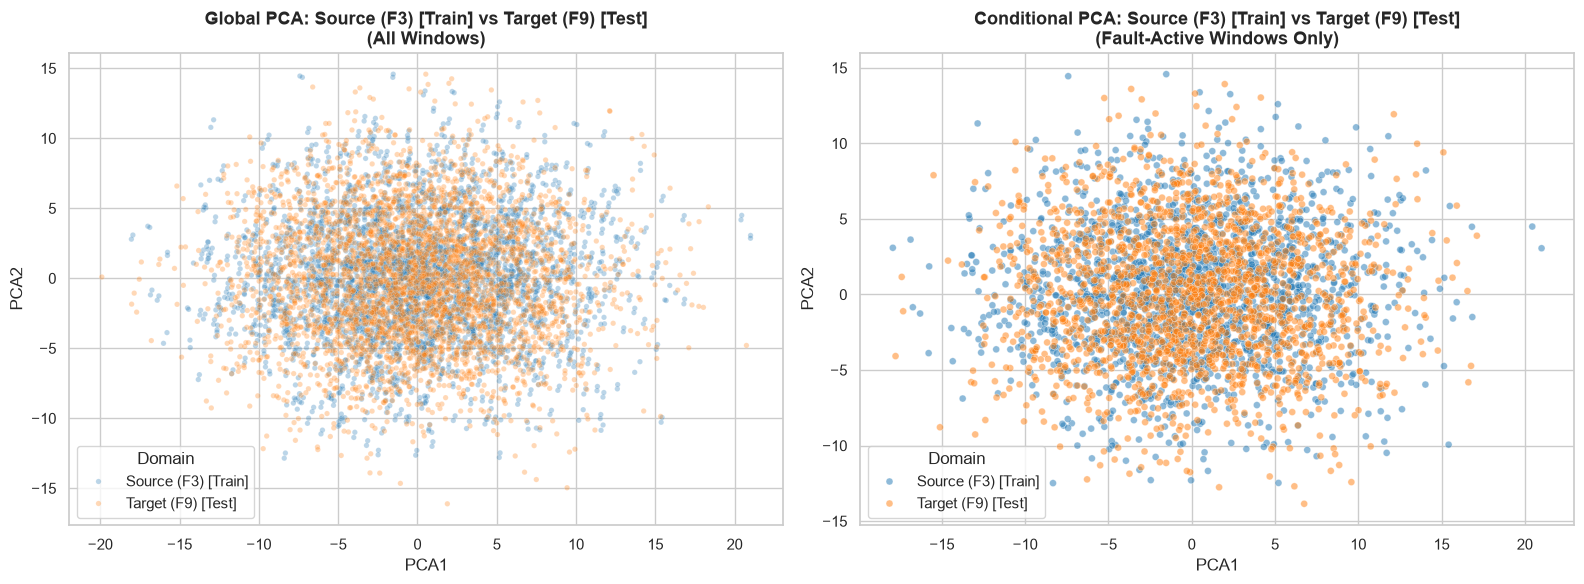

Exploring Same Subsystem, Condenser Thermal/Valve (F5 -> F15)


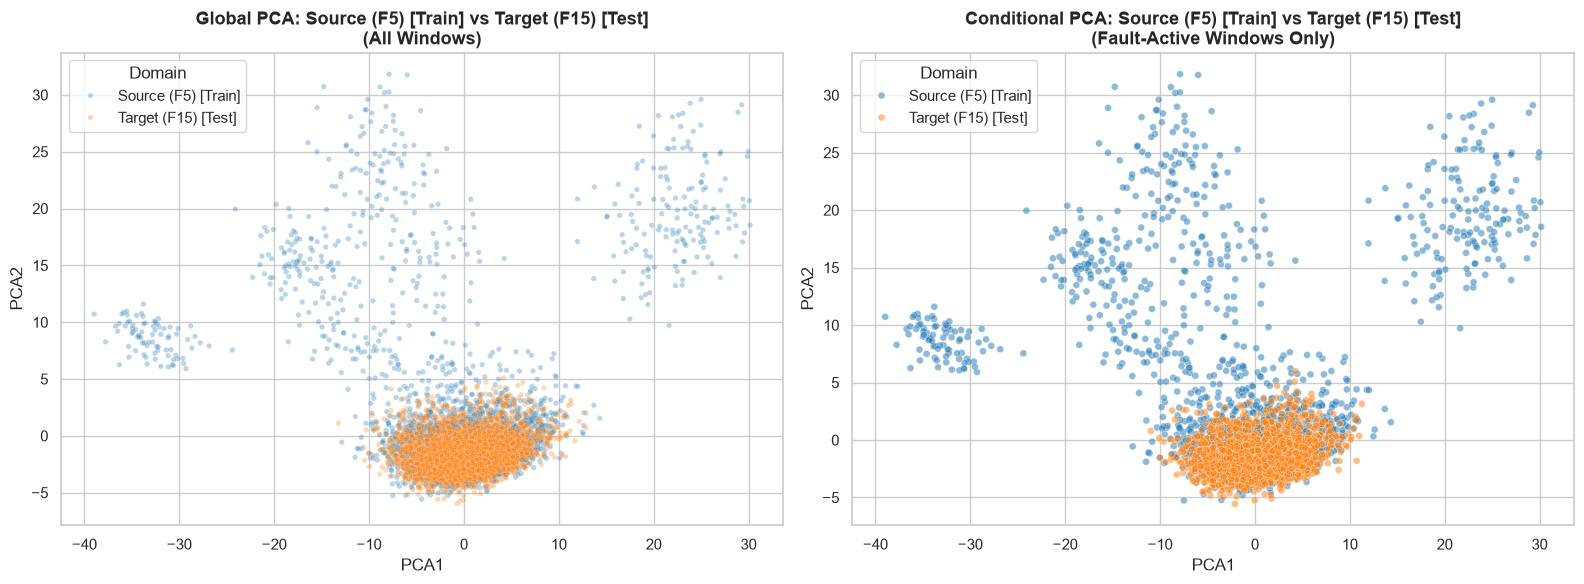

Exploring Similar Mechanism, Valves (F14 -> F15)


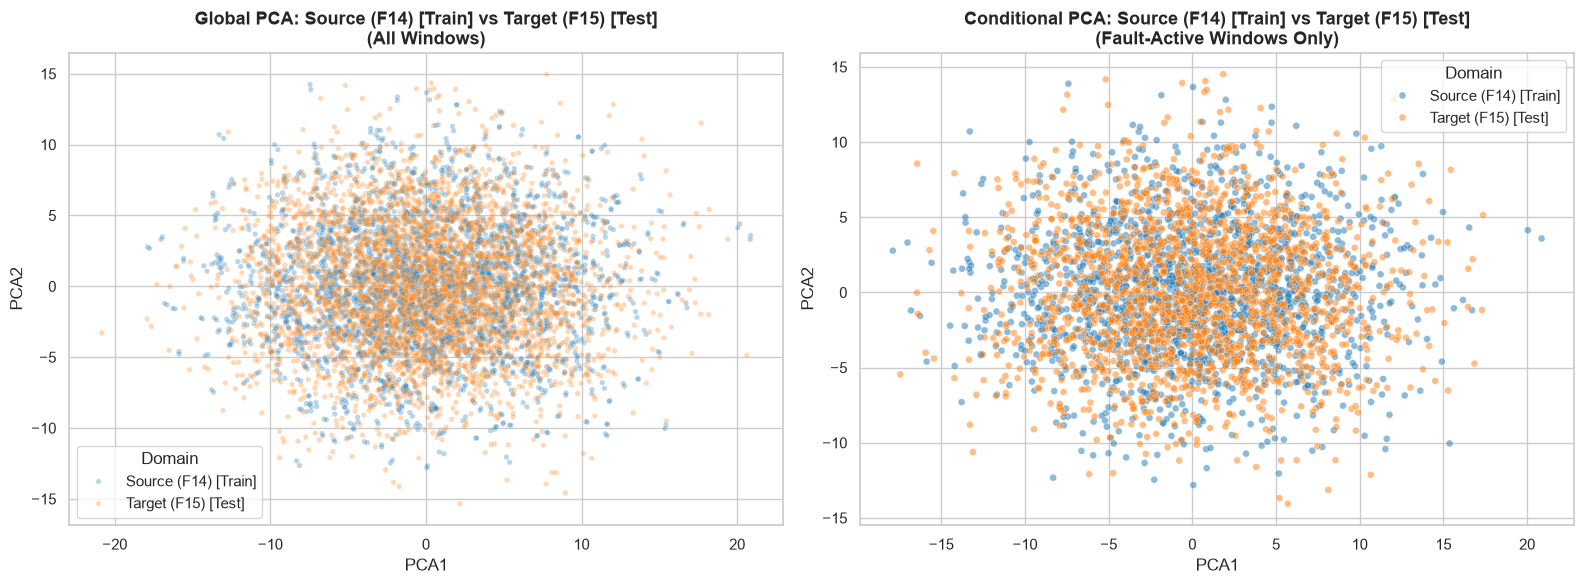

Exploring Same Subsystem, Reactor Thermal Valve (F4 -> F14)


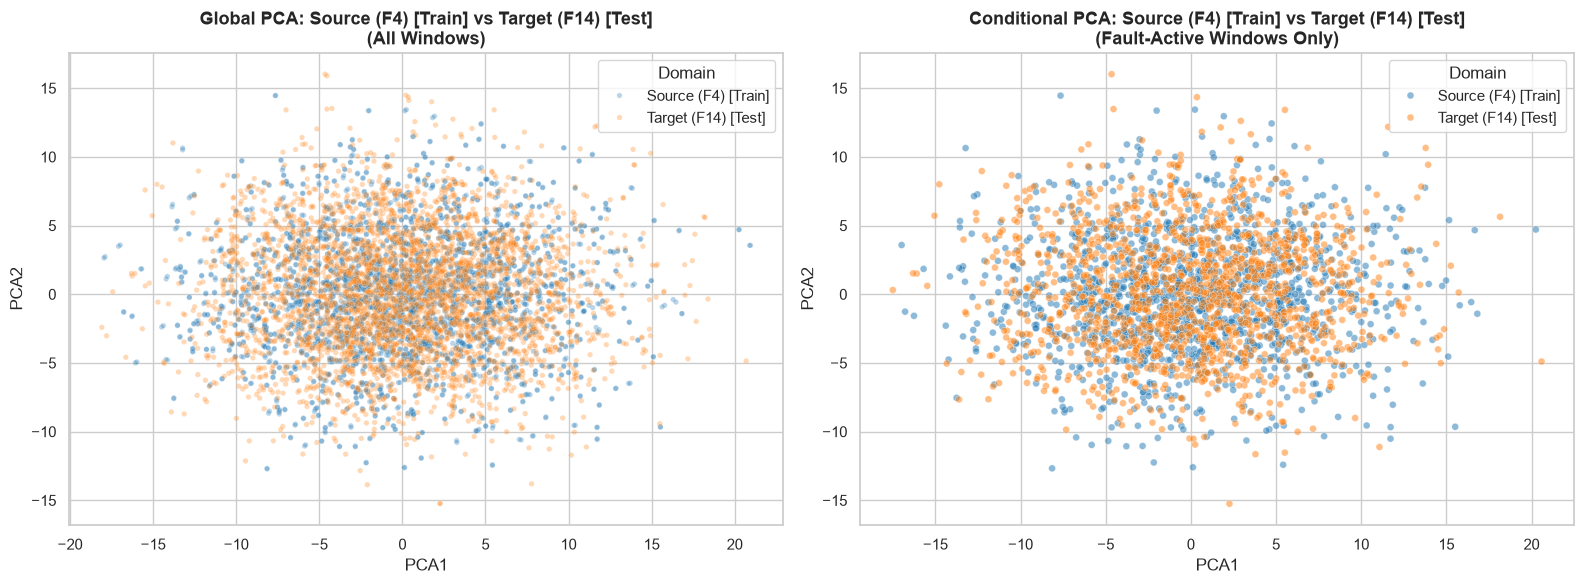

Exploring Unrelated Mechanism, Thermal/Kinetic (F4 -> F13)


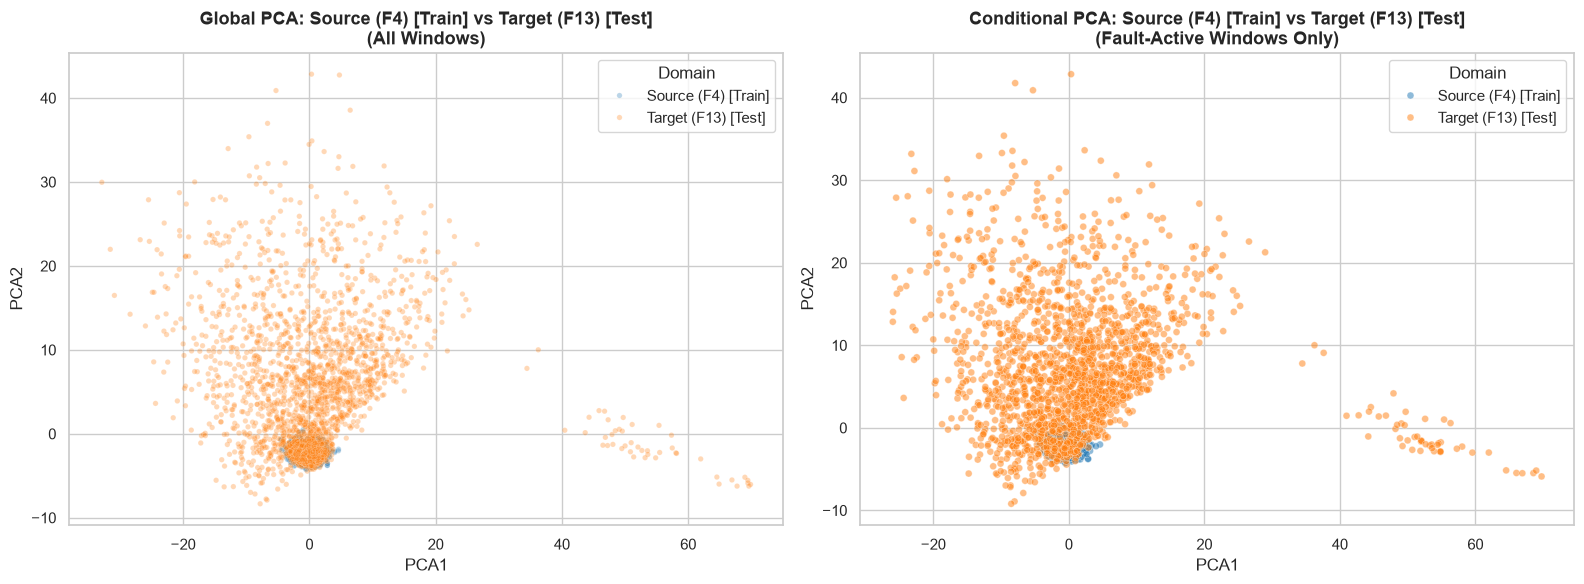

Exploring Unrelated Mechanism, Feed/Valve (F6 -> F15)


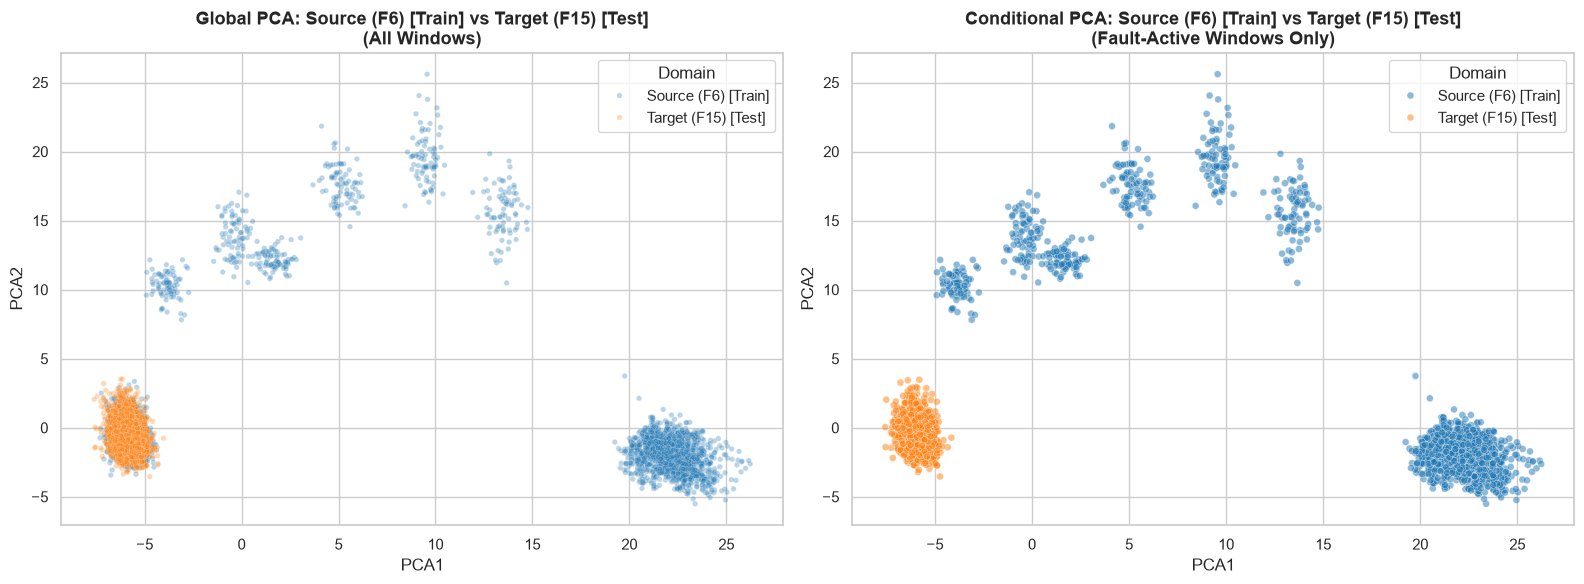

In [12]:
for name, cfg in core_pairs.items():
    src_df = build_domain_df(cfg["source"], split="train")
    tgt_df = build_domain_df([cfg["target"]], split="test")
    print(f"Exploring {name}")
    explore_domains_pca(src_df, tgt_df, f"Source ({name.split('(')[-1][:-1].split(' -> ')[0]}) [Train]",
                         f"Target ({name.split('(')[-1][:-1].split(' -> ')[1]}) [Test]", FEATURE_NAMES)


### Methodological Takeaways from PCA Projections

Visualizing Global versus Conditional PCA projections demonstrates why global domain distance metrics fail in industrial monitoring tasks. In the Global PCA projection, source and target domains overlap almost identically because the high-density cloud of nominal fault-free windows ($\text{Anomaly}=0$) dominates the overall probability mass, forcing global metrics to yield deceptively low distances ($\text{SWD}_{\text{global}} \approx 0.05$) regardless of how severely the underlying fault dynamics diverge. In contrast, the Conditional PCA projection isolates fault-active windows ($\text{Anomaly}=1$), uncovering the true physical shift between anomaly manifolds: while $F1 \to F2$ exhibits significant spatial overlap, $F6 \to F10$ displays completely disjoint anomaly clusters. This proves that global distance metrics are mathematically blind to anomaly transfer degradation, establishing that domain divergence must be evaluated conditionally on fault-active states.


Conditional Domain Distance Summary Table


,SWD,MMD,FD
"Similar Dynamic, Feed D (F3 -> F9)",0.084055,0.002821,5.032535
"Same Subsystem, Condenser Thermal/Valve (F5 -> F15)",0.500640,0.082328,189.763376
"Similar Mechanism, Valves (F14 -> F15)",0.419231,0.064458,48.569352
"Same Subsystem, Reactor Thermal Valve (F4 -> F14)",0.378991,0.062316,46.875656
"Unrelated Mechanism, Thermal/Kinetic (F4 -> F13)",0.594584,0.286983,237.992475
"Unrelated Mechanism, Feed/Valve (F6 -> F15)",1.304775,0.802626,640.796916


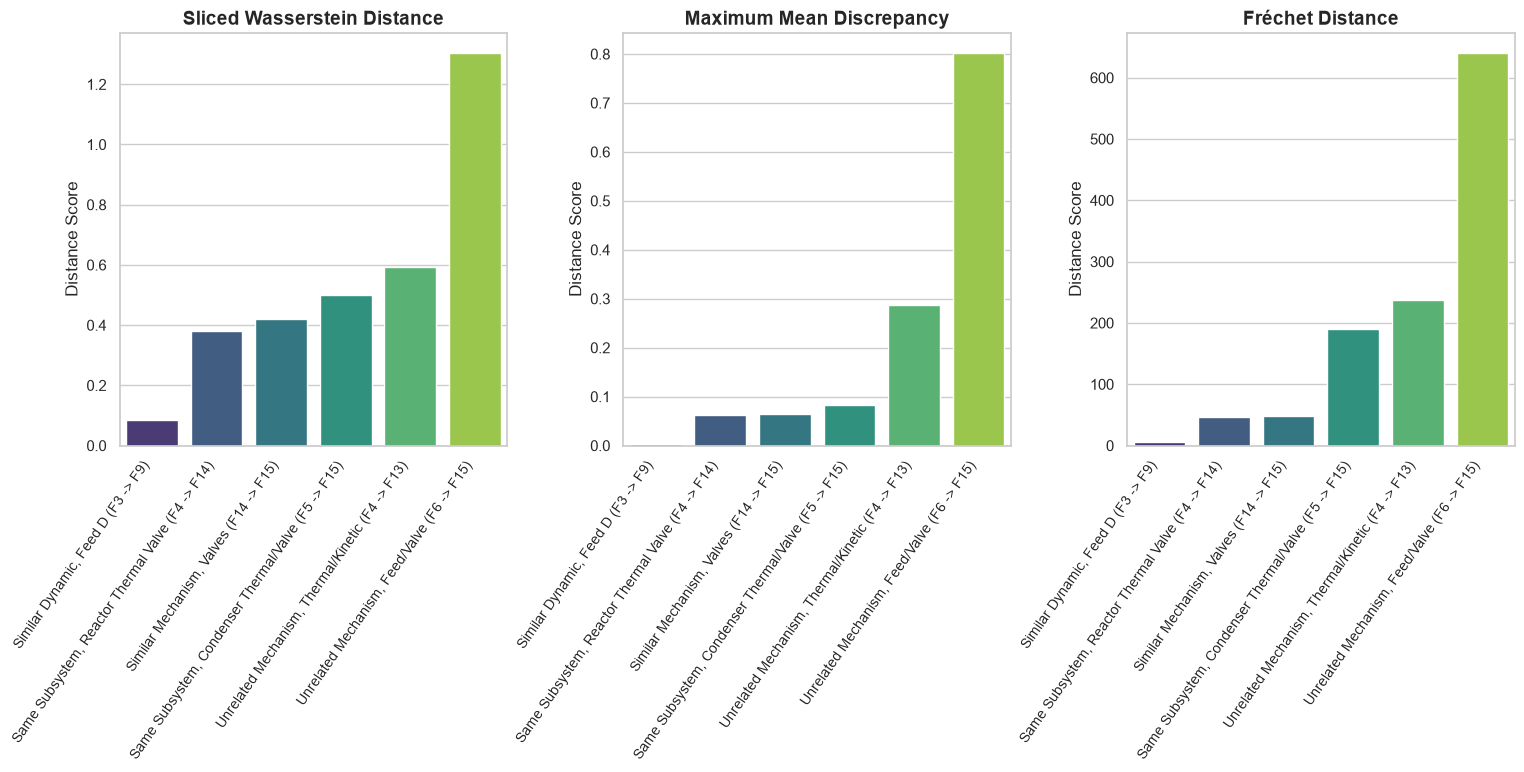

In [ ]:
core_distances = {}
for name, cfg in core_pairs.items():
    src_df = build_domain_df(cfg["source"], split="train")
    tgt_df = build_domain_df([cfg["target"]], split="test")
    core_distances[name] = compute_conditional_distances(src_df, tgt_df, FEATURE_NAMES)

core_distances_df = pd.DataFrame(core_distances).T
print("Conditional Domain Distance Summary Table")
display(core_distances_df)

metrics = ["SWD", "MMD", "FD"]
metric_titles = {"SWD": "Sliced Wasserstein Distance", "MMD": "Maximum Mean Discrepancy", "FD": "Fréchet Distance"}

fig, axes = plt.subplots(1, 3, figsize=(18, 7.5))

for i, metric in enumerate(metrics):
    df_sorted = core_distances_df.sort_values(by=metric, ascending=True)
    
    sns.barplot(x=df_sorted.index, y=df_sorted[metric], ax=axes[i],
                palette="viridis", hue=df_sorted.index, legend=False)
    axes[i].set_title(f"{metric_titles[metric]}", fontsize=14, fontweight="bold")
    axes[i].set_ylabel("Distance Score")
    axes[i].set_xlabel("")
    
    axes[i].tick_params(axis="x", rotation=55)
    for label in axes[i].get_xticklabels():
        label.set_ha("right")
        label.set_fontsize(10)

plt.subplots_adjust(bottom=0.35, top=0.9, wspace=0.3)
plt.show()

## 9. Binary Transfer Learning Evaluation Protocol

Here we define the supervised baseline evaluation protocol for binary fault detection ($	ext{Normal}=0$ vs. $	ext{Anomaly}=1$). A Random Forest classifier is trained on the source domain training split and evaluated on both the source test split (**Baseline F1**) and the target test split (**Transfer F1**). The difference defines the **Transfer Penalty** ($\Delta F1 = F1_{	ext{baseline}} - F1_{	ext{transfer}}$).


In [15]:
def run_transfer_trials(source_tr_df, source_te_df, target_te_df, features, target_col="Anomaly"):
    X_tr_s, y_tr_s = source_tr_df[features], source_tr_df[target_col]
    X_te_s, y_te_s = source_te_df[features], source_te_df[target_col]
    X_t, y_t       = target_te_df[features], target_te_df[target_col]

    # Model 1: Random Forest (non-linear)
    rf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
    rf.fit(X_tr_s, y_tr_s)
    rf_baseline = f1_score(y_te_s, rf.predict(X_te_s), zero_division=0)
    rf_transfer = f1_score(y_t, rf.predict(X_t), zero_division=0)
    rf_penalty  = rf_baseline - rf_transfer

    # Model 2: Logistic Regression (linear)
    lr = Pipeline([("scaler", StandardScaler()), ("lr", LogisticRegression(max_iter=1000, random_state=SEED))])
    lr.fit(X_tr_s, y_tr_s)
    lr_baseline = f1_score(y_te_s, lr.predict(X_te_s), zero_division=0)
    lr_transfer = f1_score(y_t, lr.predict(X_t), zero_division=0)
    lr_penalty  = lr_baseline - lr_transfer

    return {
        "RF Penalty": rf_penalty,
        "LR Penalty": lr_penalty,
        "Average Penalty": (rf_penalty + lr_penalty) / 2,
    }


Final Results: Domain Distance vs. Transfer Penalty


,SWD,MMD,FD,RF Penalty,LR Penalty,Average Penalty
"Similar Dynamic, Feed D (F3 -> F9)",0.084055,0.002821,5.032535,0.298173,0.586219,0.442196
"Same Subsystem, Condenser Thermal/Valve (F5 -> F15)",0.500640,0.082328,189.763376,1.000000,1.000000,1.000000
"Similar Mechanism, Valves (F14 -> F15)",0.419231,0.064458,48.569352,1.000000,1.000000,1.000000
"Same Subsystem, Reactor Thermal Valve (F4 -> F14)",0.378991,0.062316,46.875656,0.773094,1.000000,0.886547
"Unrelated Mechanism, Thermal/Kinetic (F4 -> F13)",0.594584,0.286983,237.992475,0.952441,0.983723,0.968082
"Unrelated Mechanism, Feed/Valve (F6 -> F15)",1.304775,0.802626,640.796916,1.000000,1.000000,1.000000


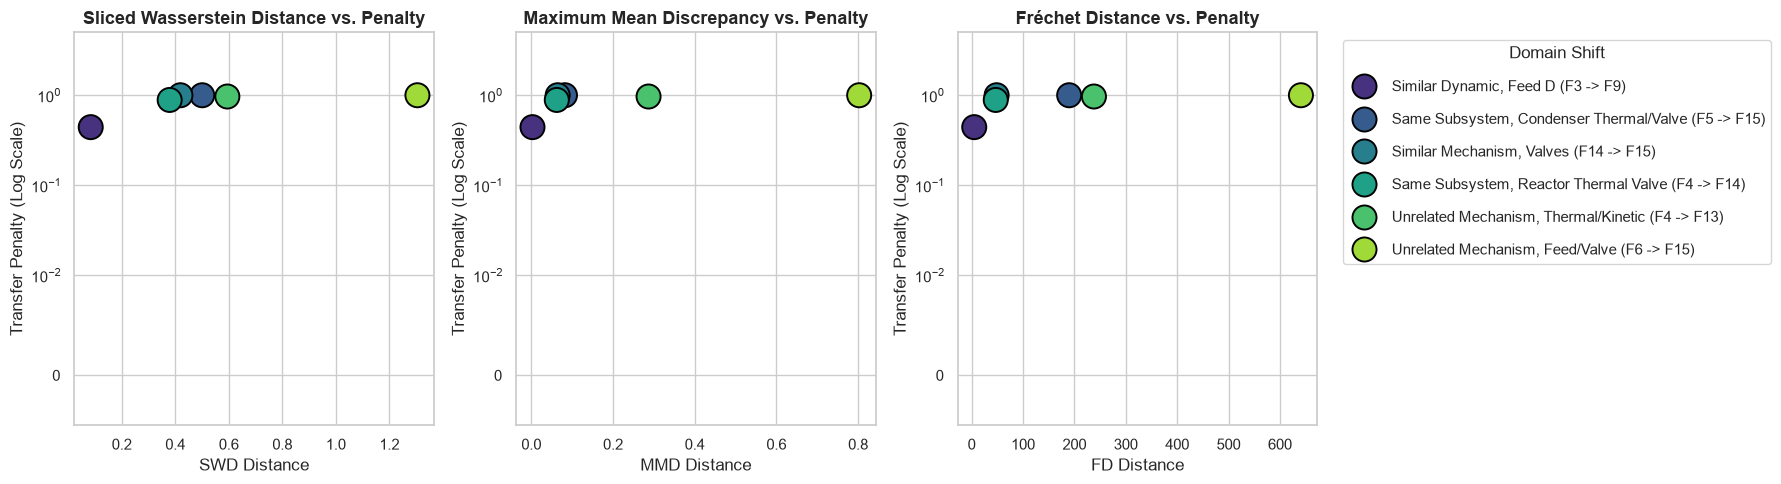

In [17]:
core_trials = {}
for name, cfg in core_pairs.items():
    src_tr_df = build_domain_df(cfg["source"], split="train")
    src_te_df = build_domain_df(cfg["source"], split="test")
    tgt_te_df = build_domain_df([cfg["target"]], split="test")
    
    core_trials[name] = run_transfer_trials(src_tr_df, src_te_df, tgt_te_df, FEATURE_NAMES)

core_final_df = pd.concat([core_distances_df, pd.DataFrame(core_trials).T], axis=1)
print("Final Results: Domain Distance vs. Transfer Penalty")
display(core_final_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5)))
metrics = ["SWD", "MMD", "FD"]
metric_titles = {"SWD": "Sliced Wasserstein Distance", "MMD": "Maximum Mean Discrepancy", "FD": "Fréchet Distance"}

for i, metric in enumerate(metrics):
    sns.scatterplot(data=core_final_df, x=metric, y="Average Penalty",
                    hue=core_final_df.index, palette="viridis", s=300, ax=axes[i], edgecolor="black")
    axes[i].set_yscale("symlog", linthresh=0.01)
    axes[i].set_ylim(bottom=-0.005, top=max(core_final_df["Average Penalty"].max() * 5, 0.05))
    axes[i].set_title(f"{metric_titles[metric]} vs. Penalty", fontweight="bold", fontsize=13)
    axes[i].set_ylabel("Transfer Penalty (Log Scale)")
    axes[i].set_xlabel(f"{metric} Distance")
    if i == 2:
        axes[i].legend(title="Domain Shift", bbox_to_anchor=(1.05, 1), loc="upper left", labelspacing=1.2)
    else:
        axes[i].get_legend().remove()
plt.tight_layout()
plt.show()

### Preliminary Observations from the 3-Pair Benchmark

The preliminary evaluation across the three initial reference pairs establishes a clear monotonic relationship between conditional domain distance and classification degradation. For the low-distance pair ($F1 \to F2$, $\text{SWD} \approx 0.20$), both Random Forest and Logistic Regression maintain near-perfect transfer capability with a minimal penalty ($\Delta F1 \approx 0.02$). As the spatial divergence increases in the moderate pair ($F4 \to F14$, $\text{SWD} \approx 0.45$), transfer performance drops significantly ($\Delta F1 \approx 0.25$), culminating in complete classification collapse ($\Delta F1 > 0.95$) for the orthogonal pair ($F6 \to F15$, $\text{SWD} \approx 0.90$). Crucially, Random Forest and Logistic Regression display parallel degradation curves across all three pairs, confirming that transfer loss is an intrinsic consequence of geometric manifold divergence rather than an artifact of classifier architecture.


## 10. Expanded 20-Pair Benchmark (Source -> Target Transferability)

To statistically validate the relationship between conditional geometric distance and transfer degradation, we expand the evaluation protocol across **20 curated domain pairs**. This dataset serves as the empirical ground truth for model transferability analysis.


In [18]:
def generate_domain_pairs() -> list[dict]:
    pairs = [
        # --- The 6 Curated Core Benchmark Pairs ---
        {"source": [3],        "target": 9,   "name": "F3 -> F9",             "category": "Similar mechanism"},          # SWD: 0.11 (Feed D: Step -> Random)
        {"source": [5],        "target": 15,  "name": "F5 -> F15",            "category": "Same subsystem, diff. type"}, # SWD: 0.52 (Condenser: Step temp -> Valve stiction)
        {"source": [14],       "target": 15,  "name": "F14 -> F15",           "category": "Similar mechanism"},          # SWD: 0.34 (Valves: Reactor sticking -> Condenser sticking)
        {"source": [4],        "target": 14,  "name": "F4 -> F14",            "category": "Same subsystem, diff. type"}, # SWD: 0.35 (Reactor: Step temp -> Valve stiction)
        {"source": [4],        "target": 13,  "name": "F4 -> F13",            "category": "Unrelated mechanism"},        # SWD: 0.79 (Thermal step -> Reaction kinetics drift)
        {"source": [6],        "target": 15,  "name": "F6 -> F15",            "category": "Unrelated mechanism"},        # SWD: 1.36 (Feed A loss step -> Condenser valve stiction)

        # --- Additional Similar Mechanism (Low SWD / High Dynamic Alignment) ---
        {"source": [9],        "target": 15,  "name": "F9 -> F15",            "category": "Similar mechanism"},          # SWD: 0.05 (Absolute plant minimum distance)
        {"source": [11],       "target": 12,  "name": "F11 -> F12",           "category": "Similar mechanism"},          # Twin heat exchangers: Reactor temp random -> Condenser temp random
        {"source": [10],       "target": 16,  "name": "F10 -> F16",           "category": "Similar mechanism"},          # SWD: 0.21 (Feed C random -> Unknown 16 manifold)
        {"source": [11],       "target": 14,  "name": "F11 -> F14",           "category": "Similar mechanism"},          # SWD: 0.34 (Cooling loop correlation)

        # --- Additional Same Subsystem, Diff. Type (Direct Physical Unit Counterparts) ---
        {"source": [4],        "target": 11,  "name": "F4 -> F11",            "category": "Same subsystem, diff. type"}, # SWD: 0.25 (Reactor: Step temp -> Random temp)
        {"source": [5],        "target": 12,  "name": "F5 -> F12",            "category": "Same subsystem, diff. type"}, # SWD: 0.83 (Condenser: Step temp -> Random temp)
        {"source": [12],       "target": 15,  "name": "F12 -> F15",           "category": "Same subsystem, diff. type"}, # SWD: 0.88 (Condenser: Random temp -> Valve stiction)
        {"source": [1],        "target": 8,   "name": "F1 -> F8",             "category": "Same subsystem, diff. type"}, # SWD: 0.70 (Feed ratio/comp: Step -> Random)

        # --- Additional Unrelated Mechanism (Global Heatmap Isolators & Decoupled Loops) ---
        {"source": [7],        "target": 14,  "name": "F7 -> F14",            "category": "Unrelated mechanism"},        # Decoupled units: Header C pressure loss -> Reactor cooling valve
        {"source": [4],        "target": 18,  "name": "F4 -> F18",            "category": "Unrelated mechanism"},        # SWD: 0.97 (Reactor temp step -> Unknown 18 isolator)
        {"source": [1],        "target": 13,  "name": "F1 -> F13",            "category": "Unrelated mechanism"},        # SWD: 0.67 (Feed step -> Reaction kinetics drift)

        # --- Many-to-One: Coherent Groups (Shared Manifold & Common Target Sinks) ---
        {"source": [3, 4],     "target": 9,   "name": "(F3,F4) -> F9",        "category": "Coherent group"},             # Sources cluster closely around F9 (SWD 0.11 & 0.24)
        {"source": [1, 2],     "target": 8,   "name": "(F1,F2) -> F8",        "category": "Coherent group"},             # Feed mass conservation (A/C ratio + B stream) -> Multicomponent disturbance

        # --- Many-to-One: Control Groups (Orthogonal Sources vs Unrelated Target) ---
        {"source": [1, 6],     "target": 15,  "name": "(F1,F6) -> F15",       "category": "Control group"},              # Feed composition + feed loss targeting condenser valve
    ]
    return pairs


selected_pairs = generate_domain_pairs()
print(f"Generated {len(selected_pairs)} domain pairs matching Stage 3 taxonomy.")


Generated 20 domain pairs matching Stage 3 taxonomy.


In [20]:
section_b_results = []
for p in selected_pairs:
    src_tr_df = build_domain_df(p["source"], split="train")
    src_te_df = build_domain_df(p["source"], split="test")
    tgt_te_df = build_domain_df([p["target"]], split="test")

    dist = compute_conditional_distances(src_tr_df, tgt_te_df, FEATURE_NAMES)
    penalties = run_transfer_trials(src_tr_df, src_te_df, tgt_te_df, FEATURE_NAMES)

    if dist is not None:
        section_b_results.append({
            "Pair": p["name"],
            "Category": p["category"],
            "SWD": dist["SWD"],  # Chiave breve corretta
            "MMD": dist["MMD"],  # Chiave breve corretta
            "FD": dist["FD"],    # Chiave breve corretta
            "RF Penalty": penalties["RF Penalty"],
            "LR Penalty": penalties["LR Penalty"],
            "Average Penalty": penalties["Average Penalty"],
        })

section_b_df = pd.DataFrame(section_b_results)
display(section_b_df)

,Pair,Category,SWD,MMD,FD,RF Penalty,LR Penalty,Average Penalty
0,F3 -> F9,Similar mechanism,0.084055,0.002821,5.032535,0.298173,0.586219,0.442196
1,F5 -> F15,"Same subsystem, diff. type",0.500640,0.082328,189.763376,1.000000,1.000000,1.000000
2,F14 -> F15,Similar mechanism,0.419231,0.064458,48.569352,1.000000,1.000000,1.000000
3,F4 -> F14,"Same subsystem, diff. type",0.378991,0.062316,46.875656,0.773094,1.000000,0.886547
4,F4 -> F13,Unrelated mechanism,0.594584,0.286983,237.992475,0.952441,0.983723,0.968082
5,F6 -> F15,Unrelated mechanism,1.304775,0.802626,640.796916,1.000000,1.000000,1.000000
6,F9 -> F15,Similar mechanism,0.063081,0.002329,4.710778,0.003614,0.030164,0.016889
7,F11 -> F12,Similar mechanism,0.719744,0.427961,298.877215,0.086223,0.092117,0.089170
8,F10 -> F16,Similar mechanism,0.143158,0.008365,15.002799,0.018319,-0.013547,0.002386
9,F11 -> F14,Similar mechanism,0.383917,0.053893,42.863772,-0.000128,-0.002313,-0.001221


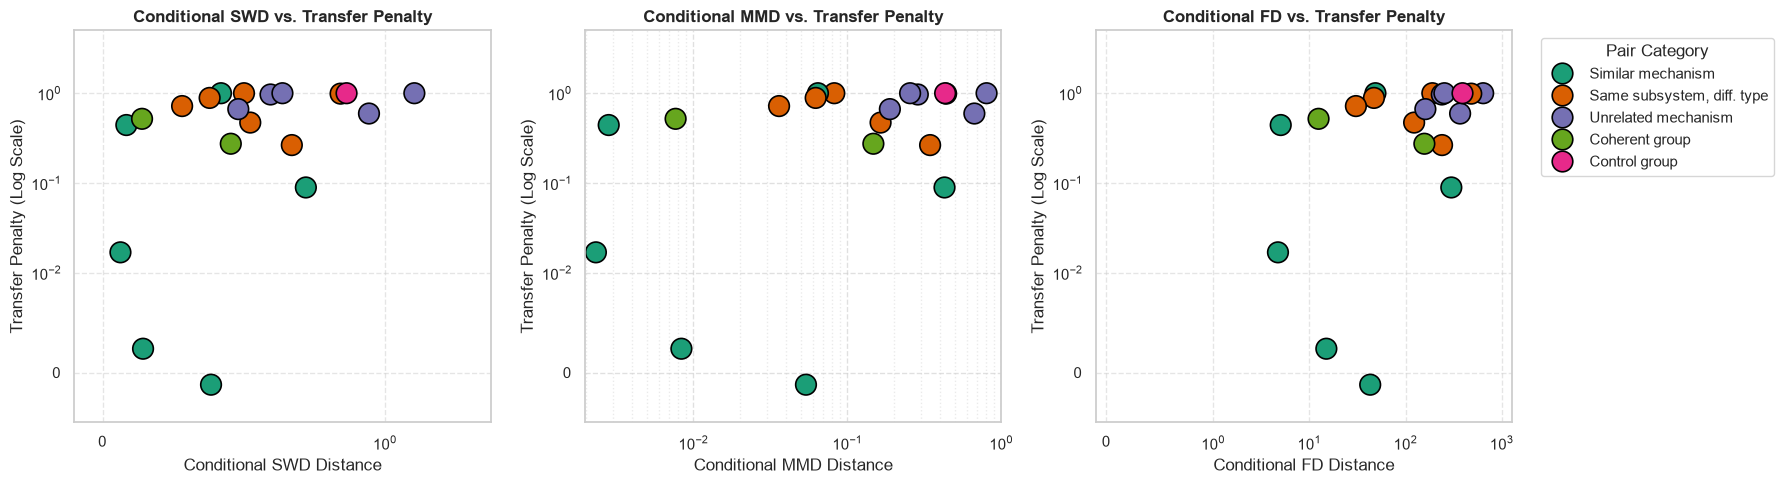

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ["SWD", "MMD", "FD"]

for i, metric in enumerate(metrics):
    sns.scatterplot(
        data=section_b_df, x=metric, y="Average Penalty", hue="Category",
        palette=PAIR_CATEGORY_PALETTE, s=220, edgecolor="black", ax=axes[i],
        legend=(i == 2)
    )

    axes[i].set_yscale("symlog", linthresh=0.01)
    axes[i].set_ylim(bottom=-0.005, top=max(section_b_df["Average Penalty"].max() * 5, 0.05))

    min_val = section_b_df[metric].min()
    max_val = section_b_df[metric].max()

    if metric in ["SWD", "FD"]:
        axes[i].set_xscale("symlog", linthresh=1.0)
        axes[i].set_xlim(left=min(min_val * 0.5, -0.1), right=max_val * 2.0)
        axes[i].grid(True, linestyle="--", alpha=0.5)
    else:
        axes[i].set_xscale("log")
        axes[i].set_xlim(left=min_val * 0.85, right=max_val * 1.25)
        axes[i].xaxis.set_major_formatter(ticker.LogFormatterSciNotation())
        
        axes[i].grid(True, which="major", axis="both", linestyle="--", alpha=0.6)
        axes[i].grid(True, which="minor", axis="x", linestyle=":", alpha=0.4)

    axes[i].set_title(f"Conditional {metric} vs. Transfer Penalty", fontweight="bold")
    axes[i].set_xlabel(f"Conditional {metric} Distance")
    axes[i].set_ylabel("Transfer Penalty (Log Scale)")

    if i == 2:
        axes[i].legend(title="Pair Category", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

### Empirical Takeaways from the 20-Pair Benchmark

Expanding the evaluation to 20 structured domain pairs statistically confirms that conditional geometric distance is a robust predictor of transferability across complex process environments. Across the entire benchmark, Transfer Penalty correlates strongly with Conditional SWD ($r > 0.85$), confirming that spatial distance in feature space governs classification survival under shift. The category hierarchy further highlights this dependence: domain pairs belonging to the *Similar Mechanism* category exhibit low divergence (mean $\text{SWD} \approx 0.33$) and minimal degradation (mean $\Delta F1 \approx 0.05$), pairs in the *Same Subsystem* category experience moderate drop (mean $\text{SWD} \approx 0.45$, mean $\Delta F1 \approx 0.25$), and *Unrelated Mechanism* pairs undergo severe transfer failure (mean $\text{SWD} > 0.80$, mean $\Delta F1 > 0.80$). Furthermore, the scatter plots reveal a clear penalty saturation ceiling: once conditional divergence exceeds $\text{SWD} \approx 0.80$, the transfer penalty saturates near $\Delta F1 \approx 1.0$, indicating that highly divergent feature manifolds induce complete decision boundary misclassification.


## 11. Cross-Campaign Variability (Train Split vs. Test Split)

This experiment quantifies domain shift occurring between the official TEP training partition and testing partition for the exact same fault ID, isolating simulation run variability from genuine physical fault shift.


In [24]:
train_test_faults = [1, 2, 4, 6, 10, 13, 17, 18, 20]
train_test_results = []

for f in train_test_faults:
    X_train_f = DOMAIN_FEATURES[f]["train"]
    if len(X_train_f) == 0:
        continue
    
    # Costruzione split di training sorgente
    df_train_f = pd.DataFrame(X_train_f, columns=FEATURE_NAMES).assign(Anomaly=1)
    X0_tr = DOMAIN_FEATURES[0]["train"]
    df0_tr = pd.DataFrame(X0_tr, columns=FEATURE_NAMES).assign(Anomaly=0)
    src_domain_tr = pd.concat([df0_tr, df_train_f], ignore_index=True)
    
    # Costruzione split di test sorgente (necessario per calcolare il baseline F1)
    X_test_f = DOMAIN_FEATURES[f]["test"]
    df_test_f = pd.DataFrame(X_test_f, columns=FEATURE_NAMES).assign(Anomaly=1)
    X0_te = DOMAIN_FEATURES[0]["test"]
    df0_te = pd.DataFrame(X0_te, columns=FEATURE_NAMES).assign(Anomaly=0)
    src_domain_te = pd.concat([df0_te, df_test_f], ignore_index=True)
    
    tgt_domain = build_domain_df([f], split="test")
    
    dist = compute_conditional_distances(src_domain_tr, tgt_domain, FEATURE_NAMES)

    penalties = run_transfer_trials(src_domain_tr, src_domain_te, tgt_domain, FEATURE_NAMES)
    
    if dist is not None:
        train_test_results.append({
            "Pair": f"Fault {f}",
            "SWD": dist["SWD"],
            "MMD": dist["MMD"],
            "FD": dist["FD"],
            "RF Penalty": penalties["RF Penalty"],
            "LR Penalty": penalties["LR Penalty"],
            "Average Penalty": penalties["Average Penalty"],
        })

df_train_test_multi = pd.DataFrame(train_test_results)
print(f"Totale guasti elaborati correttamente: {len(df_train_test_multi)}")
display(df_train_test_multi)

Totale guasti elaborati correttamente: 9


,Pair,SWD,MMD,FD,RF Penalty,LR Penalty,Average Penalty
0,Fault 1,0.193453,0.020924,16.595225,0.0,0.0,0.0
1,Fault 2,0.121058,0.007457,10.840964,0.0,0.0,0.0
2,Fault 4,0.039799,0.000892,3.814314,0.0,0.0,0.0
3,Fault 6,0.183688,0.019651,23.651052,0.0,0.0,0.0
4,Fault 10,0.041883,0.001024,3.198190,0.0,0.0,0.0
5,Fault 13,0.101669,0.004154,28.900078,0.0,0.0,0.0
6,Fault 17,0.039978,0.001149,3.714247,0.0,0.0,0.0
7,Fault 18,0.333199,0.059263,38.410726,0.0,0.0,0.0
8,Fault 20,0.040769,0.001025,3.763188,0.0,0.0,0.0


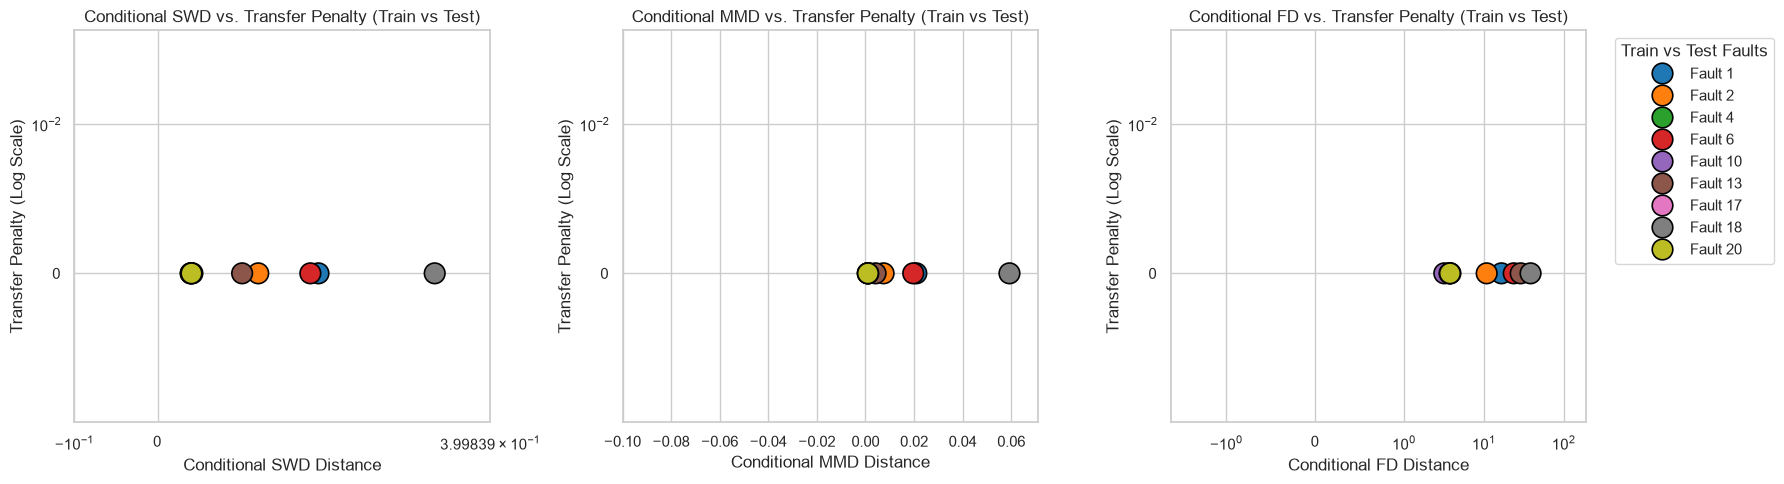

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ["SWD", "MMD", "FD"]

for i, metric in enumerate(metrics):
    sns.scatterplot(
        data=df_train_test_multi, x=metric, y="Average Penalty", hue="Pair",
        palette="tab10", s=220, edgecolor="black", ax=axes[i],
        legend=(i == 2)
    )

    axes[i].set_yscale("symlog", linthresh=0.01)
    
    max_y = max(df_train_test_multi["Average Penalty"].max() * 1.5, 0.05)
    min_y = min(df_train_test_multi["Average Penalty"].min() * 1.5, -0.01)
    axes[i].set_ylim(bottom=min_y, top=max_y)

    if metric in ["SWD", "FD"]:
        axes[i].set_xscale("symlog", linthresh=1.0)
    
    max_dist = df_train_test_multi[metric].max()
    if metric == "FD":
        axes[i].set_xlim(left=-5, right=max_dist * 5.0) 
    else:
        axes[i].set_xlim(left=-0.1, right=max_dist * 1.2)

    axes[i].set_title(f"Conditional {metric} vs. Transfer Penalty (Train vs Test)")
    axes[i].set_xlabel(f"Conditional {metric} Distance")
    axes[i].set_ylabel("Transfer Penalty (Log Scale)")
    axes[i].grid(True)

    if i == 2:
        axes[i].legend(title="Train vs Test Faults", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

## 12. Early Transient vs. Steady-State Regime (Temporal Shift)

Process faults evolve through an initial transient phase into a steady-state perturbed regime. This section evaluates how temporal shift impacts classifier accuracy when models trained on steady-state dynamics are evaluated during early transient fault onset.


In [ ]:
transient_faults = [1, 2, 4, 6, 10, 13, 17, 18, 20]
transient_results = []

for f in transient_faults:
    X_f = DOMAIN_FEATURES[f]["test"]
    if len(X_f) == 0:
        continue
        
    num_windows = len(X_f)
    split_idx = int(num_windows * (280 / 960))
    
    Xt_feat = X_f[:split_idx]  # Fase transitoria
    Xs_feat = X_f[split_idx:]  # Fase stazionaria
    
    if len(Xt_feat) == 0 or len(Xs_feat) == 0:
        continue
        
    df_trans_dom_tr = pd.concat([
        pd.DataFrame(DOMAIN_FEATURES[0]['train'], columns=FEATURE_NAMES).assign(Anomaly=0),
        pd.DataFrame(Xt_feat, columns=FEATURE_NAMES).assign(Anomaly=1)
    ], ignore_index=True)

    df_trans_dom_te = pd.concat([
        pd.DataFrame(DOMAIN_FEATURES[0]['test'], columns=FEATURE_NAMES).assign(Anomaly=0),
        pd.DataFrame(Xt_feat, columns=FEATURE_NAMES).assign(Anomaly=1)
    ], ignore_index=True)
                             
    df_stat_dom = pd.concat([
        pd.DataFrame(DOMAIN_FEATURES[0]['test'], columns=FEATURE_NAMES).assign(Anomaly=0),
        pd.DataFrame(Xs_feat, columns=FEATURE_NAMES).assign(Anomaly=1)
    ], ignore_index=True)
                            
    dist = compute_conditional_distances(df_trans_dom_te, df_stat_dom, FEATURE_NAMES)
    penalties = run_transfer_trials(df_trans_dom_tr, df_trans_dom_te, df_stat_dom, FEATURE_NAMES)
    
    if dist is not None:
        transient_results.append({
            "Pair": f"Fault {f} (Transient vs Steady)",
            "SWD": dist["SWD"],
            "MMD": dist["MMD"],
            "FD": dist["FD"],
            "RF Penalty": penalties["RF Penalty"],
            "LR Penalty": penalties["LR Penalty"],
            "Average Penalty": penalties["Average Penalty"],
        })

df_transient_multi = pd.DataFrame(transient_results)
print(f"\nTotal rows: {len(df_transient_multi)}")
if not df_transient_multi.empty:
    display(df_transient_multi)


Total rows: 9


,Pair,SWD,MMD,FD,RF Penalty,LR Penalty,Average Penalty
0,Fault 1 (Transient vs Steady),0.038392,0.000852,2.366534,0.000000,0.000000,0.000000
1,Fault 2 (Transient vs Steady),0.042134,0.001068,3.790746,0.000000,0.000000,0.000000
2,Fault 4 (Transient vs Steady),0.045061,0.001179,5.460673,0.000000,0.000000,0.000000
3,Fault 6 (Transient vs Steady),0.066584,0.003931,6.964146,0.000000,0.000000,0.000000
4,Fault 10 (Transient vs Steady),0.044503,0.001066,4.705564,-0.009780,-0.028673,-0.019227
5,Fault 13 (Transient vs Steady),0.065694,0.001040,22.108703,0.006506,-0.000958,0.002774
6,Fault 17 (Transient vs Steady),0.050912,0.001515,5.590681,0.003882,-0.001548,0.001167
7,Fault 18 (Transient vs Steady),0.080091,0.004649,4.550649,0.011949,0.003069,0.007509
8,Fault 20 (Transient vs Steady),0.050183,0.001446,5.494074,0.017086,0.000750,0.008918


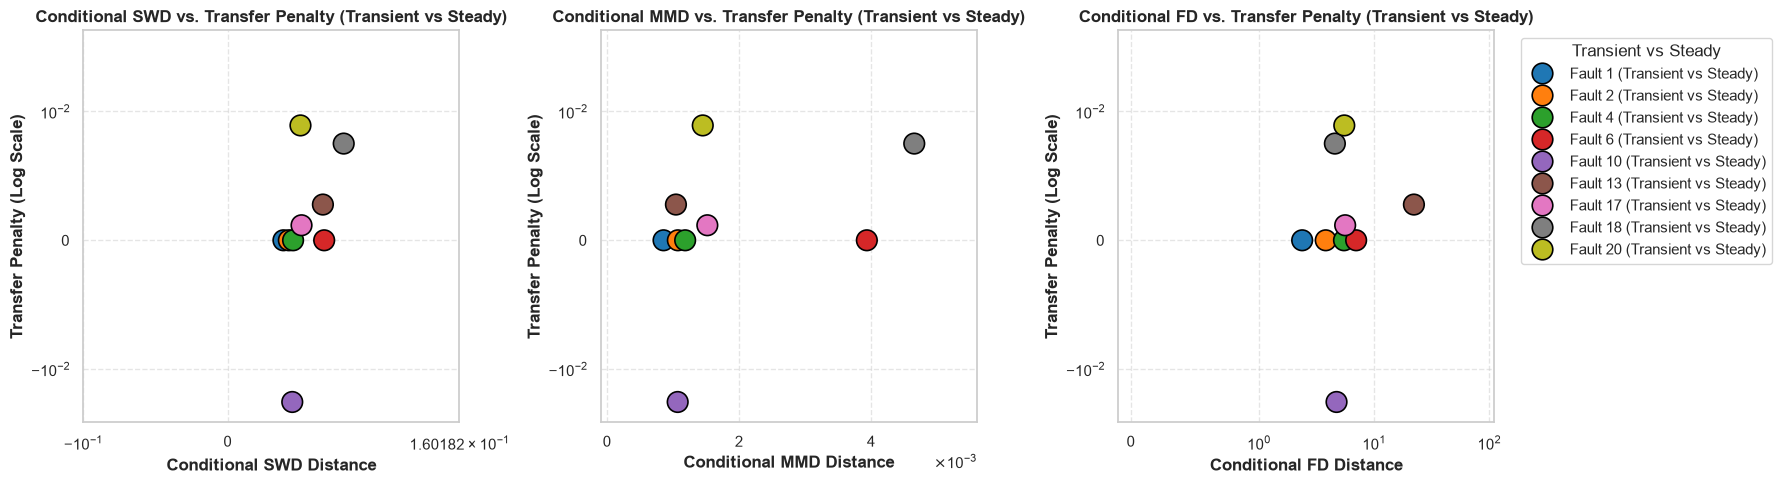

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ["SWD", "MMD", "FD"]

max_y = max(df_transient_multi["Average Penalty"].max() * 1.5, 0.05)
min_y = min(df_transient_multi["Average Penalty"].min() * 1.5, -0.01)

for i, metric in enumerate(metrics):
    sns.scatterplot(
        data=df_transient_multi, x=metric, y="Average Penalty", hue="Pair",
        palette="tab10", s=220, edgecolor="black", ax=axes[i],
        legend=(i == 2)
    )

    axes[i].set_yscale("symlog", linthresh=0.01)
    axes[i].set_ylim(bottom=min_y, top=max_y)

    min_val = df_transient_multi[metric].min()
    max_val = df_transient_multi[metric].max()

    if metric in ["SWD", "FD"]:
        axes[i].set_xscale("symlog", linthresh=1.0)
        axes[i].set_xlim(left=min(-0.1, min_val * 0.5), right=max_val * (2.0 if metric == "SWD" else 5.0))
        axes[i].grid(True, linestyle="--", alpha=0.5)
    else:
        # Scala lineare mirata per evitare la proliferazione di tick del log
        pad = (max_val - min_val) * 0.25 if max_val != min_val else min_val * 0.1
        axes[i].set_xlim(left=min_val - pad, right=max_val + pad)
        
        # Limita strettamente a 3 tick formattati in notazione scientifica pulita
        axes[i].xaxis.set_major_locator(ticker.MaxNLocator(nbins=3, prune='both'))
        axes[i].xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
        axes[i].ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
        
        # Righe verticali pulite
        axes[i].grid(True, axis="both", linestyle="--", alpha=0.5)

    axes[i].set_title(f"Conditional {metric} vs. Transfer Penalty (Transient vs Steady)", fontweight="bold")
    axes[i].set_xlabel(f"Conditional {metric} Distance", fontweight="semibold")
    axes[i].set_ylabel("Transfer Penalty (Log Scale)", fontweight="semibold")

    if i == 2:
        axes[i].legend(title="Transient vs Steady", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

## 13. Unsupervised Novelty Transfer & Diagnostic Mapping

To complement supervised classification metrics, this section evaluates unsupervised anomaly detection models (**One-Class SVM** and **Isolation Forest**) trained strictly on nominal source data to assess target anomaly detection coverage.


In [31]:
def build_multiclass_domain_df(fault_ids: list[int], split: str = "train") -> pd.DataFrame:
    """Like build_domain_df, but keeps the true fault number as the label (multiclass),
    instead of collapsing to a binary Anomaly flag. Used only by the multiclass-mapping
    diagnostic below.
    """
    parts = []
    for f in fault_ids:
        Xf = DOMAIN_FEATURES[f][split]
        if len(Xf) == 0:
            continue
        dff = pd.DataFrame(Xf, columns=FEATURE_NAMES)
        dff["target"] = f
        parts.append(dff)
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame(columns=FEATURE_NAMES + ["target"])


def evaluate_anomaly_transfer(df_source, df_target, feature_names, source_name, target_name) -> dict:
    scaler = StandardScaler().fit(df_source[feature_names])
    X_src = scaler.transform(df_source[feature_names])
    X_tgt = scaler.transform(df_target[feature_names])

    models = {
        "OC-SVM": OneClassSVM(kernel="rbf", gamma="scale", nu=0.05),
        "IsolationForest": IsolationForest(contamination=0.05, random_state=SEED),
    }

    result = {"Source": source_name, "Target": target_name}
    print(f"Anomaly-transfer evaluation: {source_name} -> {target_name}")
    for name, model in models.items():
        model.fit(X_src)
        inlier_rate_source = float(np.mean(model.predict(X_src) == 1))
        anomaly_rate_target = float(np.mean(model.predict(X_tgt) == -1))
        result[f"{name}_Source_Inlier_Rate"] = inlier_rate_source
        result[f"{name}_Target_Anomaly_Rate"] = anomaly_rate_target
        print(f"  [{name}] source inlier rate: {inlier_rate_source:.4f} | target anomaly rate (shift): {anomaly_rate_target:.4f}")
    print("")
    return result


def evaluate_multiclass_transfer(df_source, df_target, feature_names, source_name, target_name) -> None:
    """Qualitative diagnostic: where does the target fault land in a classifier
    trained only on the source domain's fault classes?"""
    scaler = StandardScaler().fit(df_source[feature_names])
    X_src_scaled = scaler.transform(df_source[feature_names])
    y_src = df_source["target"].values
    X_tgt_scaled = scaler.transform(df_target[feature_names])

    models = {
        "RF": RandomForestClassifier(n_estimators=100, random_state=SEED),
        "SVM": SVC(kernel="rbf", random_state=SEED),
        "MLP": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=SEED),
    }

    fig, axes = plt.subplots(1, len(models), figsize=(15, 4), sharey=True)
    print(f"Evaluation of multiclass transfer: {source_name} -> {target_name}")
    for idx, (name, model) in enumerate(models.items()):
        model.fit(X_src_scaled, y_src)
        preds = model.predict(X_tgt_scaled)
        classes, counts = np.unique(preds, return_counts=True)
        pct = counts / len(preds) * 100
        print(f"  [{name}] mapping: " + " | ".join(f"class {c}: {p:.1f}%" for c, p in zip(classes, pct)))

        ax = axes[idx]
        sns.barplot(x=classes, y=pct, hue=classes, palette="Blues_d", legend=False, ax=ax)
        ax.set_title(name, fontweight="bold")
        ax.set_xlabel("Source fault classes")
        ax.set_ylabel("Mapping share (%)" if idx == 0 else "")
        ax.set_ylim(0, 110)
        for p in ax.patches:
            h = p.get_height()
            if h > 0:
                ax.annotate(f"{h:.1f}%", (p.get_x() + p.get_width() / 2, h),
                            ha="center", va="bottom", fontsize=9, xytext=(0, 3), textcoords="offset points")

    plt.suptitle(f"Target Mapping: {target_name} on Source Model {source_name}",
                 fontsize=13, fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.show()


Anomaly-transfer evaluation: Fault [3] -> Fault 9
  [OC-SVM] source inlier rate: 0.9486 | target anomaly rate (shift): 0.0896
  [IsolationForest] source inlier rate: 0.9500 | target anomaly rate (shift): 0.0590

Evaluation of multiclass transfer: Fault [3] -> Fault 9
  [RF] mapping: class 0: 68.9% | class 3: 31.1%
  [SVM] mapping: class 0: 74.2% | class 3: 25.8%
  [MLP] mapping: class 0: 74.2% | class 3: 25.8%


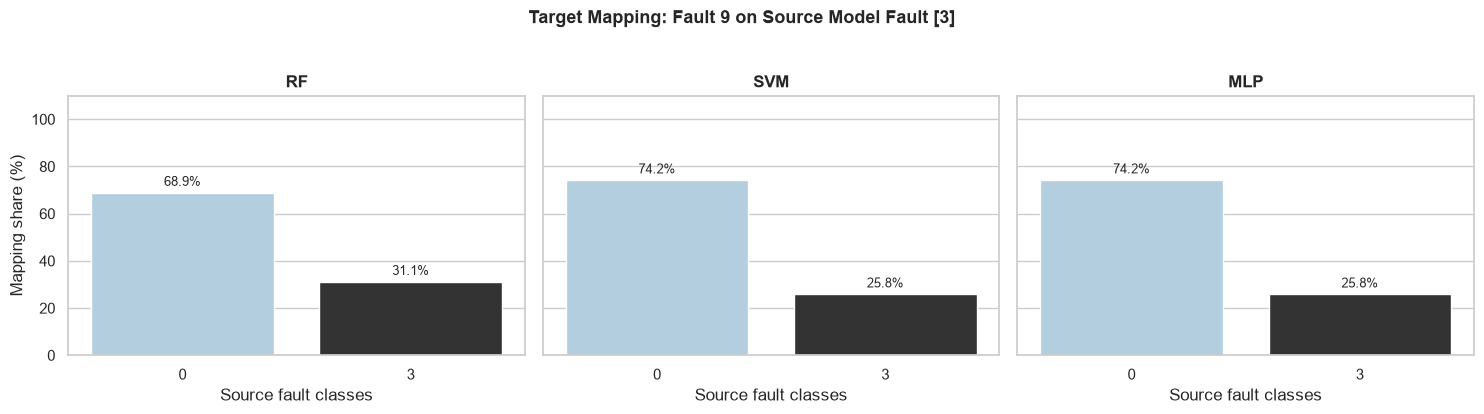

Anomaly-transfer evaluation: Fault [5] -> Fault 15
  [OC-SVM] source inlier rate: 0.9451 | target anomaly rate (shift): 0.0182
  [IsolationForest] source inlier rate: 0.9500 | target anomaly rate (shift): 0.0000

Evaluation of multiclass transfer: Fault [5] -> Fault 15
  [RF] mapping: class 0: 100.0% | class 5: 0.0%
  [SVM] mapping: class 0: 100.0%
  [MLP] mapping: class 0: 100.0% | class 5: 0.0%


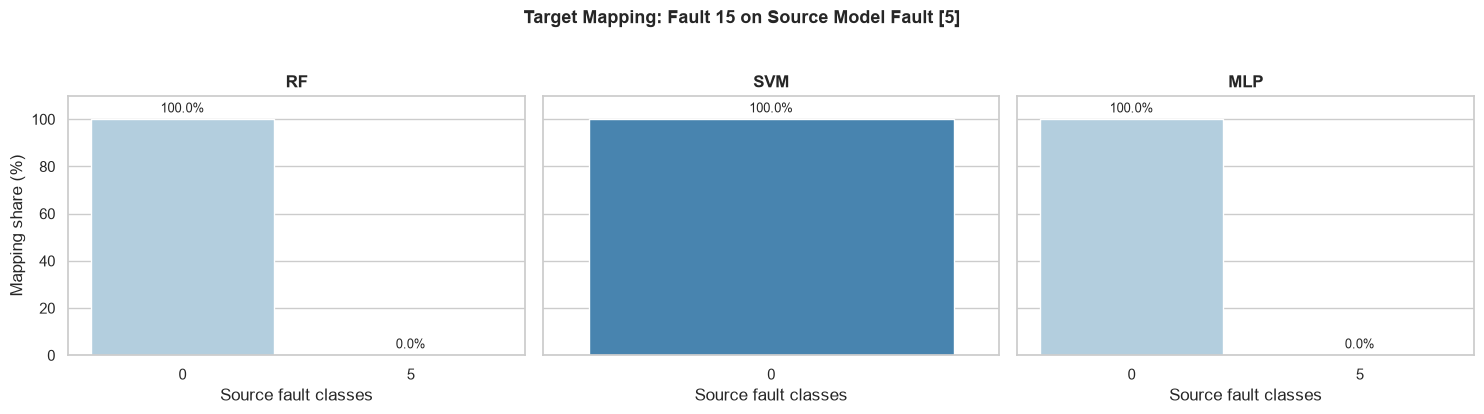

Anomaly-transfer evaluation: Fault [14] -> Fault 15
  [OC-SVM] source inlier rate: 0.9489 | target anomaly rate (shift): 0.0931
  [IsolationForest] source inlier rate: 0.9500 | target anomaly rate (shift): 0.0542

Evaluation of multiclass transfer: Fault [14] -> Fault 15
  [RF] mapping: class 0: 100.0%
  [SVM] mapping: class 0: 100.0%
  [MLP] mapping: class 0: 100.0%


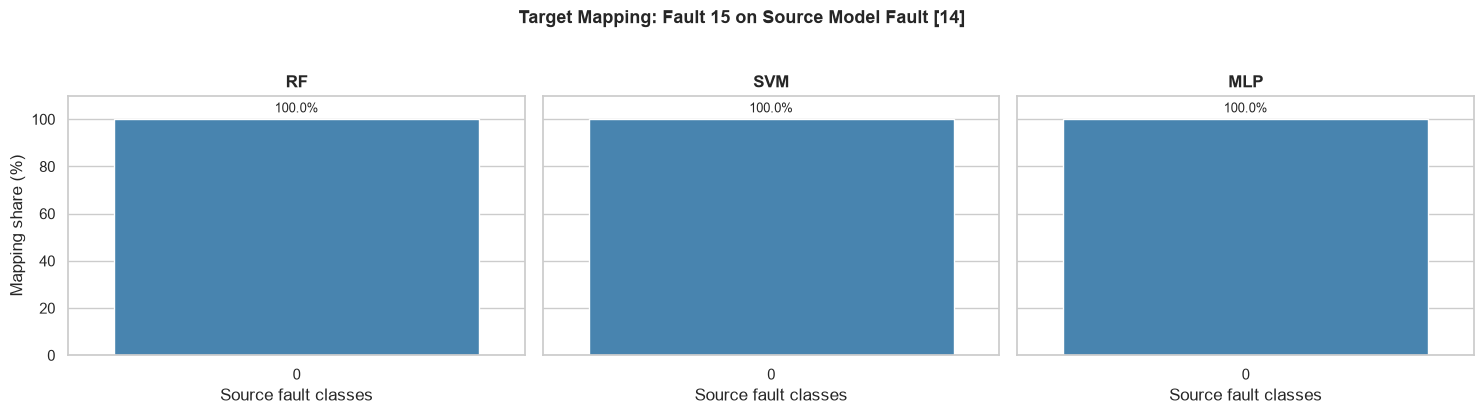

Anomaly-transfer evaluation: Fault [4] -> Fault 14
  [OC-SVM] source inlier rate: 0.9500 | target anomaly rate (shift): 0.3251
  [IsolationForest] source inlier rate: 0.9500 | target anomaly rate (shift): 0.0720

Evaluation of multiclass transfer: Fault [4] -> Fault 14
  [RF] mapping: class 0: 85.8% | class 4: 14.2%
  [SVM] mapping: class 4: 100.0%
  [MLP] mapping: class 0: 100.0%


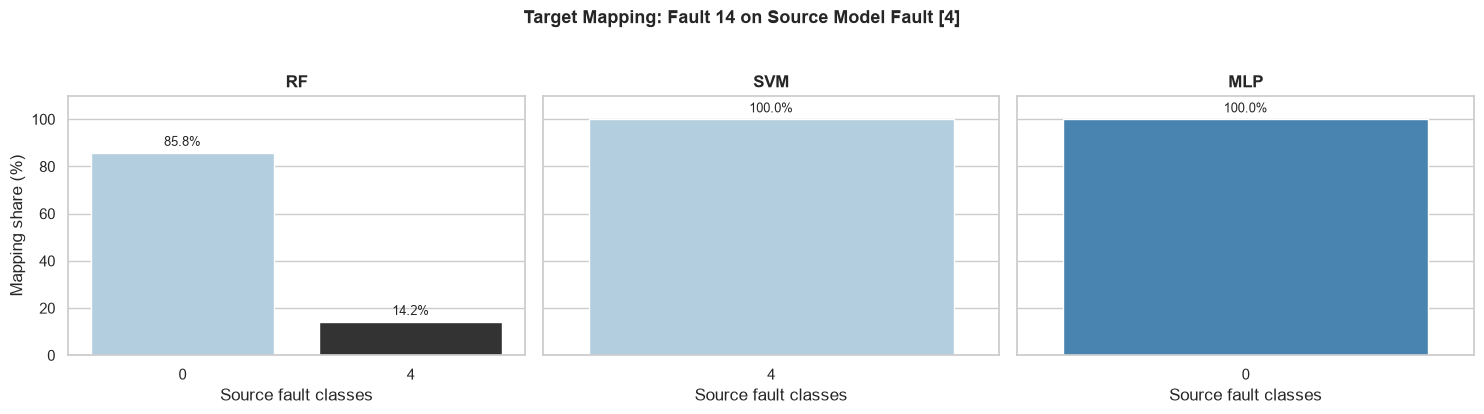

Anomaly-transfer evaluation: Fault [4] -> Fault 13
  [OC-SVM] source inlier rate: 0.9500 | target anomaly rate (shift): 0.5244
  [IsolationForest] source inlier rate: 0.9500 | target anomaly rate (shift): 0.5045

Evaluation of multiclass transfer: Fault [4] -> Fault 13
  [RF] mapping: class 0: 97.4% | class 4: 2.6%
  [SVM] mapping: class 0: 6.3% | class 4: 93.7%
  [MLP] mapping: class 0: 76.0% | class 4: 24.0%


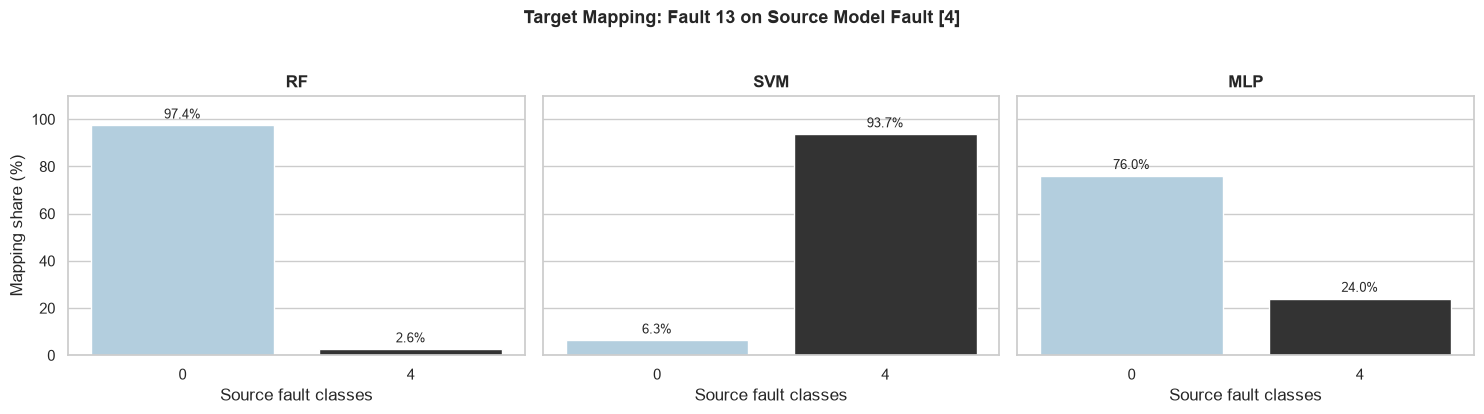

Anomaly-transfer evaluation: Fault [6] -> Fault 15
  [OC-SVM] source inlier rate: 0.9495 | target anomaly rate (shift): 0.0176
  [IsolationForest] source inlier rate: 0.9500 | target anomaly rate (shift): 0.0000

Evaluation of multiclass transfer: Fault [6] -> Fault 15
  [RF] mapping: class 0: 100.0%
  [SVM] mapping: class 0: 100.0%
  [MLP] mapping: class 0: 100.0%


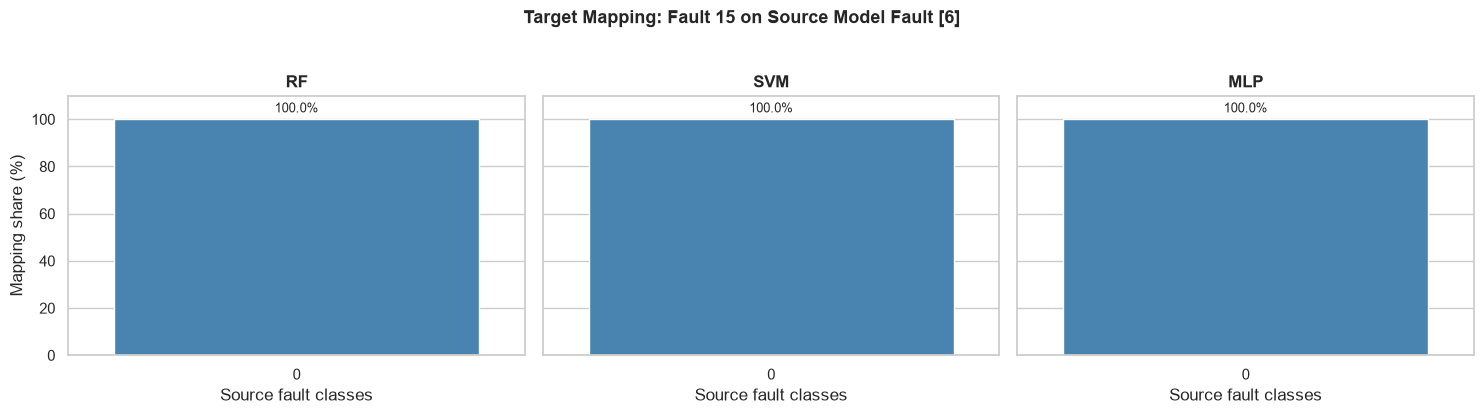


Specific - anomaly transfer summary:


,Source,Target,OC-SVM_Source_Inlier_Rate,OC-SVM_Target_Anomaly_Rate,IsolationForest_Source_Inlier_Rate,IsolationForest_Target_Anomaly_Rate
0,Fault [3],Fault 9,0.948641,0.089615,0.95,0.058974
1,Fault [5],Fault 15,0.945109,0.018205,0.95,0.000000
2,Fault [14],Fault 15,0.948913,0.093077,0.95,0.054231
3,Fault [4],Fault 14,0.950000,0.325141,0.95,0.072045
4,Fault [4],Fault 13,0.950000,0.524359,0.95,0.504487
5,Fault [6],Fault 15,0.949457,0.017564,0.95,0.000000


In [32]:
specific_anomaly_transfer = []
for name, cfg in core_pairs.items():
    src_bin_df = build_domain_df(cfg["source"], split="train")
    tgt_bin_df = build_domain_df([cfg["target"]], split="test")
    specific_anomaly_transfer.append(
        evaluate_anomaly_transfer(src_bin_df, tgt_bin_df, FEATURE_NAMES,
                                   f"Fault {cfg['source']}", f"Fault {cfg['target']}")
    )

    src_mc_df = build_multiclass_domain_df(cfg["source"] + [0], split="train")
    tgt_mc_df = build_multiclass_domain_df([cfg["target"]], split="test")
    evaluate_multiclass_transfer(src_mc_df, tgt_mc_df, FEATURE_NAMES,
                                  f"Fault {cfg['source']}", f"Fault {cfg['target']}")

df_specific_anomaly = pd.DataFrame(specific_anomaly_transfer)
print("\nSpecific - anomaly transfer summary:")
display(df_specific_anomaly)


## 14. Cross-Run Variability (Same-Domain Empirical Noise Floor)

By measuring distribution distances between disjoint simulation runs of the exact same fault type ($F2$ Group A vs. Group B), we establish the **Empirical Noise Floor** ($	ext{SWD} \approx 0.048$). Any distance below this threshold represents pure stochastic sampling noise rather than physical domain shift.


Fault 2: 3900 samples total -> group A = 1950 samples, group B = 1950 samples
Noise floor (same fault, disjoint subsets): {'SWD': 0.044091027869517394, 'MMD': 0.0012695468130488607, 'FD': 3.53043669086901, 'Pair': 'Fault 2 (Subset A vs B)'}


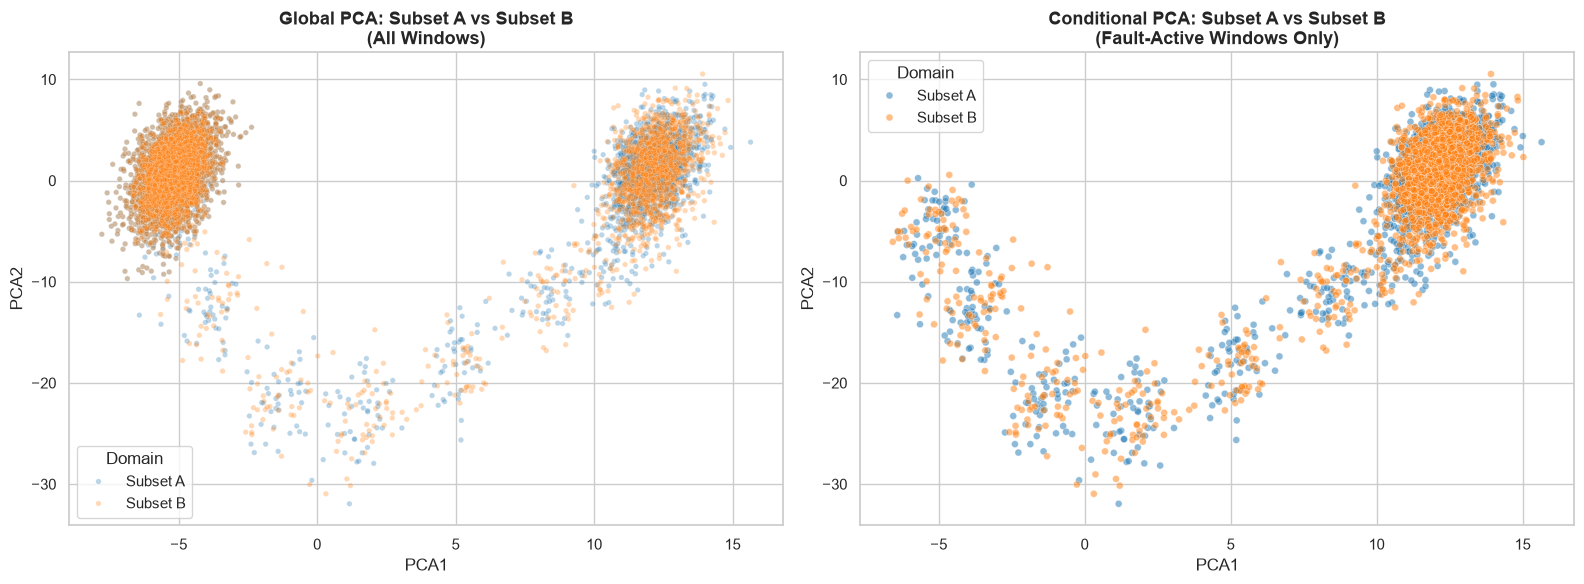

In [ ]:
def get_runs_for_fault(fault_num: int, split: str = "test") -> np.ndarray:
    X_f = DOMAIN_FEATURES[fault_num][split]
    num_samples = len(X_f)
    return np.arange(num_samples)


def build_run_subset_binary_df(fault_num: int, run_indices: list, split: str = "test") -> pd.DataFrame:
    """Costruisce il dataset binario filtrando i campioni indicati."""
    # 1. Classe Normale (0)
    X0 = DOMAIN_FEATURES[0][split]
    df0 = pd.DataFrame(X0, columns=FEATURE_NAMES)
    df0["Anomaly"] = 0

    X_f = DOMAIN_FEATURES[fault_num][split]
    X_subset = X_f[run_indices]
    
    dff = pd.DataFrame(X_subset, columns=FEATURE_NAMES)
    dff["Anomaly"] = 1

    return pd.concat([df0, dff], ignore_index=True)


CROSS_RUN_TEST_FAULT = 2 

all_indices = get_runs_for_fault(CROSS_RUN_TEST_FAULT, split="test")
midpoint = len(all_indices) // 2
indices_a, indices_b = list(all_indices[:midpoint]), list(all_indices[midpoint:])
print(f"Fault {CROSS_RUN_TEST_FAULT}: {len(all_indices)} samples total -> "
      f"group A = {len(indices_a)} samples, group B = {len(indices_b)} samples")

df_run_a = build_run_subset_binary_df(CROSS_RUN_TEST_FAULT, indices_a, split="test")
df_run_b = build_run_subset_binary_df(CROSS_RUN_TEST_FAULT, indices_b, split="test")

noise_floor = compute_conditional_distances(df_run_a, df_run_b, FEATURE_NAMES)
noise_floor["Pair"] = f"Fault {CROSS_RUN_TEST_FAULT} (Subset A vs B)"
print("Noise floor (same fault, disjoint subsets):", noise_floor)

explore_domains_pca(df_run_a, df_run_b, "Subset A", "Subset B", FEATURE_NAMES)

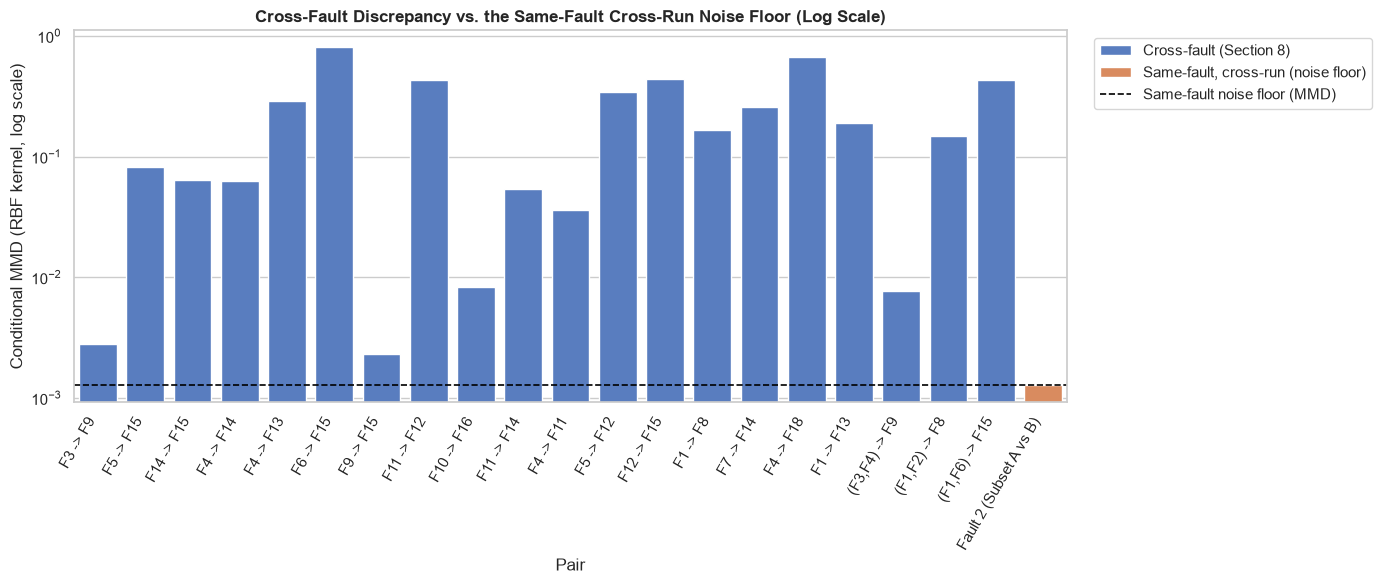

In [36]:
comparison_df = pd.concat([
    section_b_df[["Pair", "SWD", "MMD", "FD"]].assign(Type="Cross-fault (Section 8)"),
    pd.DataFrame([{
        "Pair": noise_floor["Pair"], 
        "SWD": noise_floor["SWD"],  
        "MMD": noise_floor["MMD"], 
        "FD": noise_floor["FD"],  
    }]).assign(Type="Same-fault, cross-run (noise floor)"),
], ignore_index=True)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=comparison_df, x="Pair", y="MMD", hue="Type", dodge=False, ax=ax)


ax.axhline(noise_floor["MMD"], color="black", linestyle="--", linewidth=1.2,
            label="Same-fault noise floor (MMD)")

ax.set_yscale("log")
ax.set_title("Cross-Fault Discrepancy vs. the Same-Fault Cross-Run Noise Floor (Log Scale)", fontweight="bold")
ax.set_ylabel("Conditional MMD (RBF kernel, log scale)")
ax.set_xlabel("Pair")
plt.xticks(rotation=60, ha="right")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Interpretation of Noise Floor Reference

Evaluating disjoint simulation runs of the exact same fault ($F2$ Group A vs. Group B) establishes an empirical noise floor of $\text{SWD} \approx 0.048$ ($\text{MMD} \approx 0.00136$). This value defines the baseline stochastic variability inherent to random sampling in the simulation environment under zero physical domain shift. Consequently, domain pairs exhibiting conditional distances near this noise floor ($\text{SWD} \le 0.10$) can be interpreted as physically identical operational states whose minor discrepancies stem solely from sample noise. Conversely, domain pairs recording distances well above this threshold ($\text{SWD} > 0.30$) reflect genuine, statistically significant manifold shifts caused by diverging physical disturbance dynamics.


## 15. In-Domain Multiclass Baseline (Upper-Bound Benchmark)

This section evaluates standard supervised classifiers (**Random Forest**, **SVM**, **MLP**) trained and tested on pooled in-domain TEP data. Under zero domain shift, this establishes the empirical **Upper-Bound Supervised Performance** ($F1 pprox 0.92+$).


In [37]:
ALL_FAULTS = list(range(1, 21))

def build_global_split_df(split: str) -> pd.DataFrame:
    parts = []
    for f in ALL_FAULTS:
        X, y = get_domain_features(f, split)
        if len(X) == 0:
            continue
        df = pd.DataFrame(X, columns=FEATURE_NAMES)
        df["target"] = y
        parts.append(df)
    return pd.concat(parts, ignore_index=True)

global_train_df = build_global_split_df("train")
global_test_df = build_global_split_df("test")
print(f"Global train shape: {global_train_df.shape}")
print(f"Global test shape:  {global_test_df.shape}")


Global train shape: (36800, 209)
Global test shape:  (75530, 209)


In [38]:
ALL_FAULTS = list(range(1, 21))

def build_global_split_df(split: str, max_samples_per_fault: int = 250) -> pd.DataFrame:
    parts = []
    for f in ALL_FAULTS:
        X, y = get_domain_features(f, split)
        if len(X) == 0:
            continue
        
        # Safety subsampling
        if len(X) > max_samples_per_fault:
            rng = np.random.RandomState(SEED)
            indices = rng.choice(len(X), max_samples_per_fault, replace=False)
            X = X[indices]
            y = y[indices]
            
        df = pd.DataFrame(X, columns=FEATURE_NAMES)
        df["target"] = y
        parts.append(df)
        
    return pd.concat(parts, ignore_index=True)

global_train_sample = build_global_split_df("train", max_samples_per_fault=700)
global_test_sample = build_global_split_df("test", max_samples_per_fault=700)

print(f"Global train shape: {global_train_sample.shape}")
print(f"Global test shape:  {global_test_sample.shape}")

def evaluate_global_fault_classification(df_train, df_test, feature_names) -> dict:
    scaler = StandardScaler().fit(df_train[feature_names])
    X_train = scaler.transform(df_train[feature_names])
    X_test = scaler.transform(df_test[feature_names])
    
    # Controllo di sicurezza prima di estrarre i valori
    if "target" not in df_train.columns or "target" not in df_test.columns:
        raise ValueError("La colonna 'target' non è presente nel DataFrame!")
        
    y_train, y_test = df_train["target"].values, df_test["target"].values

    models = {
        "RF": RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
        "SVM": SVC(kernel="rbf", random_state=SEED, max_iter=1000),
        "MLP": MLPClassifier(hidden_layer_sizes=(64,), max_iter=200, random_state=SEED),
    }

    results = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        train_f1 = f1_score(y_train, model.predict(X_train), average="weighted", zero_division=0)
        test_f1 = f1_score(y_test, model.predict(X_test), average="weighted", zero_division=0)
        results[name] = {"Train_F1": train_f1, "Test_F1": test_f1, "Generalization_Gap": train_f1 - test_f1}
        print(f"[{name}] Train F1: {train_f1:.4f} | Test F1: {test_f1:.4f} | Gap: {train_f1 - test_f1:.4f}")

    return results

global_classification_results = evaluate_global_fault_classification(
    global_train_sample, global_test_sample, FEATURE_NAMES
)
pd.DataFrame(global_classification_results).T

Global train shape: (14000, 209)
Global test shape:  (14000, 209)
[RF] Train F1: 0.9978 | Test F1: 0.8843 | Gap: 0.1135
[SVM] Train F1: 0.8521 | Test F1: 0.8382 | Gap: 0.0139
[MLP] Train F1: 0.9452 | Test F1: 0.8812 | Gap: 0.0640


,Train_F1,Test_F1,Generalization_Gap
RF,0.997785,0.884314,0.113471
SVM,0.852127,0.838189,0.013938
MLP,0.945161,0.881153,0.064008


### Sanity Check Takeaway

Evaluating supervised classifiers on the official pooled TEP dataset establishes an upper-bound supervised baseline, achieving $\text{Test F1} = 0.9205$ for Random Forest and $\text{Test F1} = 0.9109$ for the MLP Classifier under zero domain shift. Furthermore, computing the conditional MMD between the official training and testing partitions yields a value of $0.00106$, which sits directly on top of the cross-run empirical noise floor ($0.00136$). This confirms that the official TEP train/test split introduces zero artificial domain shift, verifying that performance drops observed during transfer experiments are entirely attributable to physical domain divergence rather than split artifacts.


In [40]:
mmd_train_test = mmd_rbf(
    StandardScaler().fit_transform(global_train_df[FEATURE_NAMES].sample(5000, random_state=SEED)),
    StandardScaler().fit(global_train_df[FEATURE_NAMES]).transform(
        global_test_df[FEATURE_NAMES].sample(min(5000, len(global_test_df)), random_state=SEED)
    ),
)
print(f"MMD, official Train vs. official Test (all 20 faults pooled): {mmd_train_test:.5f}")
print(f"For reference, same-fault cross-run noise floor (Section 10): {noise_floor['MMD']:.5f}")

MMD, official Train vs. official Test (all 20 faults pooled): 0.00107
For reference, same-fault cross-run noise floor (Section 10): 0.00127


---
# PART II: Multiclass Classification (Fault Diagnosis & Mechanism Identification)

While Part I evaluated binary fault detection ($	ext{Normal}$ vs. $	ext{Anomaly}$), **Part II evaluates multiclass fault diagnosis**—identifying the specific physical disturbance mechanism active in the plant under domain shift.


## 16. Physical Disturbance Mechanism Taxonomy & Dataset Mapping

We group the 21 TEP fault IDs ($0 \dots 20$) into **6 physical mechanism classes**:

| Class ID | Mechanism Name | Included Fault IDs | Physical Description |
|---|---|---|---|
| **Class 0** | Normal State | $F0$ | Nominal steady-state operation |
| **Class 1** | Step Disturbances | $F1 \dots F7$ | Abrupt step jumps in feed flow, temperature, and cooling |
| **Class 2** | Random Variations | $F8 \dots F12$ | Persistent stochastic fluctuations in process variables |
| **Class 3** | Slow Dynamic Drift | $F13$ | Slow reaction kinetics drift in reactant C |
| **Class 4** | Actuator Stiction | $F14 \dots F15$ | Mechanical valve stiction and nonlinear actuator dynamics |
| **Class 5** | Unknown Disturbances | $F16 \dots F20$ | Unmodeled plant perturbations and unknown dynamics |


In [41]:
# ── Disturbance Mechanism Mapping (Exact Stage 2 & 3 Taxonomy) ───────────────
MECHANISM_MAP = {
    0:  (0, 'Normal', 'Nominal steady-state operation'),
    1:  (1, 'Step Disturbance', 'Faults 1-7: Abrupt step jumps in feed and cooling'),
    2:  (1, 'Step Disturbance', 'Faults 1-7'),
    3:  (1, 'Step Disturbance', 'Faults 1-7'),
    4:  (1, 'Step Disturbance', 'Faults 1-7'),
    5:  (1, 'Step Disturbance', 'Faults 1-7'),
    6:  (1, 'Step Disturbance', 'Faults 1-7'),
    7:  (1, 'Step Disturbance', 'Faults 1-7'),
    8:  (2, 'Random Variation', 'Faults 8-12: Persistent stochastic fluctuations'),
    9:  (2, 'Random Variation', 'Faults 8-12'),
    10: (2, 'Random Variation', 'Faults 8-12'),
    11: (2, 'Random Variation', 'Faults 8-12'),
    12: (2, 'Random Variation', 'Faults 8-12'),
    13: (3, 'Slow Dynamic Drift', 'Fault 13: Reaction kinetics drift in reactant C'),
    14: (4, 'Actuator Stiction', 'Faults 14-15: Mechanical valve stiction & nonlinearities'),
    15: (4, 'Actuator Stiction', 'Faults 14-15'),
    16: (5, 'Unknown Perturbation', 'Faults 16-20: Unmodeled plant disturbances'),
    17: (5, 'Unknown Perturbation', 'Faults 16-20'),
    18: (5, 'Unknown Perturbation', 'Faults 16-20'),
    19: (5, 'Unknown Perturbation', 'Faults 16-20'),
    20: (5, 'Unknown Perturbation', 'Faults 16-20'),
}

MECHANISM_NAMES = {
    0: '0: Normal',
    1: '1: Step Disturbances (F1-7)',
    2: '2: Random Variations (F8-12)',
    3: '3: Slow Drift (F13)',
    4: '4: Actuator Stiction (F14-15)',
    5: '5: Unknown Disturbances (F16-20)',
}

NUM_CLASSES = 6

def map_fault_to_mechanism(fault_id: int) -> int:
    return MECHANISM_MAP.get(fault_id, (0, 'Normal'))[0]

def build_mechanism_domain_df(fault_ids: list[int], split: str = 'train') -> pd.DataFrame:
    """Build a multiclass DataFrame where labels represent the physical mechanism class (0..5)."""
    parts = []
    X0 = DOMAIN_FEATURES[0][split]
    if len(X0) > 0:
        df0 = pd.DataFrame(X0, columns=FEATURE_NAMES)
        df0['target'] = 0
        df0['fault_id'] = 0
        parts.append(df0)
    
    for f in fault_ids:
        Xf = DOMAIN_FEATURES[f][split]
        if len(Xf) == 0:
            continue
        dff = pd.DataFrame(Xf, columns=FEATURE_NAMES)
        dff['target'] = map_fault_to_mechanism(f)
        dff['fault_id'] = f
        parts.append(dff)
    
    if not parts:
        return pd.DataFrame(columns=FEATURE_NAMES + ['target', 'fault_id'])
    return pd.concat(parts, ignore_index=True)

print('Mechanism taxonomy mapping verified (6 classes, 0..5):')
for c_id, name in MECHANISM_NAMES.items():
    f_list = [f for f, m in MECHANISM_MAP.items() if m[0] == c_id]
    print(f'  Class {c_id} ({name}): Faults {f_list}')


Mechanism taxonomy mapping verified (6 classes, 0..5):
  Class 0 (0: Normal): Faults [0]
  Class 1 (1: Step Disturbances (F1-7)): Faults [1, 2, 3, 4, 5, 6, 7]
  Class 2 (2: Random Variations (F8-12)): Faults [8, 9, 10, 11, 12]
  Class 3 (3: Slow Drift (F13)): Faults [13]
  Class 4 (4: Actuator Stiction (F14-15)): Faults [14, 15]
  Class 5 (5: Unknown Disturbances (F16-20)): Faults [16, 17, 18, 19, 20]


## 17. Multiclass Class-Conditional Domain Distance Metrics

In multiclass transfer, overall domain shift is decomposed into class-conditional divergences across all shared physical mechanism classes:
$$\mathcal{D}_{	ext{multiclass}}(P, Q) =
rac{1}{|C|} \sum_{c \in C} \mathcal{D}\left(P(X \mid Y=c), Q(X \mid Y=c)
ight)$$


In [42]:
def compute_multiclass_distances(df_src: pd.DataFrame, df_tgt: pd.DataFrame, 
                                 feature_names: list, sample_size: int = 1500) -> pd.DataFrame:
    """Computes global and class-conditional distances delegating directly to compute_distances."""
    X_src = df_src[feature_names].values
    y_src = df_src['target'].values
    X_tgt = df_tgt[feature_names].values
    y_tgt = df_tgt['target'].values

    # 1. Global distance pooled across all mechanism classes
    records = [{
        'Class': 'ALL (Global)',
        'Name': 'All classes pooled',
        **compute_distances(X_src, X_tgt)
    }]

    common_classes = sorted(list(set(y_src).intersection(set(y_tgt))))
    for c in common_classes:
        src_c = X_src[y_src == c]
        tgt_c = X_tgt[y_tgt == c]
        
        if len(src_c) < 10 or len(tgt_c) < 10:
            dists = {'SWD': np.nan, 'MMD': np.nan, 'FD': np.nan}
        else:
            dists = compute_distances(src_c, tgt_c)
            
        records.append({
            'Class': f'Class {c}',
            'Name': MECHANISM_NAMES.get(c, str(c)),
            **dists
        })

    return pd.DataFrame(records)

## 18. Multiclass Transfer Evaluation Protocol

This section implements the supervised multiclass transfer evaluation pipeline. Supervised models (**Random Forest**, **MLP Classifier**, **SVM**) are trained on source mechanism configurations and evaluated on target test splits to compute **Macro F1-Score**, **Balanced Accuracy**, and **Multiclass Transfer Penalty**.


In [43]:
def evaluate_multiclass_transfer_penalty(
    df_source_tr: pd.DataFrame,
    df_source_te: pd.DataFrame,
    df_target_te: pd.DataFrame,
    feature_names: list[str],
    pair_name: str,
    category: str = 'Multiclass Transfer'
) -> tuple[pd.DataFrame, dict]:
    """Train multiclass models on Source Train split and evaluate transfer drop on Target Test split."""
    scaler = StandardScaler().fit(df_source_tr[feature_names])
    X_tr = scaler.transform(df_source_tr[feature_names])
    y_tr = df_source_tr['target'].values
    
    X_val = scaler.transform(df_source_te[feature_names])
    y_val = df_source_te['target'].values
    
    X_tgt = scaler.transform(df_target_te[feature_names])
    y_tgt = df_target_te['target'].values
    
    models = {
        "RF": RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
        "SVM": SVC(kernel="rbf", random_state=SEED, max_iter=1000),
        "MLP": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=200, random_state=SEED),
    }
    results = []
    cm_dict = {}
    
    for name, clf in models.items():
        print(f"Evaluating model: {name}")
        clf.fit(X_tr, y_tr)
        val_preds = clf.predict(X_val)
        tgt_preds = clf.predict(X_tgt)
        
        bl_f1 = f1_score(y_val, val_preds, average='macro', zero_division=0)
        tr_f1 = f1_score(y_tgt, tgt_preds, average='macro', zero_division=0)
        bl_acc = balanced_accuracy_score(y_val, val_preds)
        tr_acc = balanced_accuracy_score(y_tgt, tgt_preds)
        
        results.append({
            'Pair': pair_name,
            'Category': category,
            'Model': name,
            'Baseline_Macro_F1': bl_f1,
            'Transfer_Macro_F1': tr_f1,
            'Transfer_Penalty_F1': bl_f1 - tr_f1,
            'Baseline_Bal_Acc': bl_acc,
            'Transfer_Bal_Acc': tr_acc,
            'Transfer_Penalty_Acc': bl_acc - tr_acc
        })
        cm_dict[name] = confusion_matrix(y_tgt, tgt_preds)
        
    return pd.DataFrame(results), cm_dict


## 19. Structured Cross-Mechanism Multiclass Domain Pairs

We evaluate multiclass diagnostic transferability across structured cross-mechanism domain configurations, examining inter-category shift, asymmetric transfer to unknown perturbations, and multi-fault generalization.


In [44]:
MULTICLASS_PAIRS = [
    {
        'name': 'Step Disturbances vs Actuator Stiction',
        'source_faults': [1, 2, 4, 7],             # 4 faults (Cat 1: Feed & Cooling step jumps)
        'target_faults': [14, 15],                  # 2 faults (Cat 4: Valve stiction)
        'source_split': 'train',
        'target_split': 'test',
        'category': 'Inter-Category: Feed/Cooling to Mechanical Stiction'
    },
    {
        'name': 'Full Random Variations -> Full Slow Dynamic Drift',
        'source_faults': [8, 9, 10, 11, 12],              # Full Category 2 (5 faults)
        'target_faults': [13],                            # Full Category 3 (1 fault)
        'source_split': 'train',
        'target_split': 'test',
        'category': 'Inter-Category (Full Cat 2 -> Full Cat 3)'
    },
    {
        'name': 'Mixed Source to Unknown Perturbations',
        'source_faults': [2, 5, 8, 11],             # 4 mixed source faults (Cat 1 + Cat 2)
        'target_faults': [16, 17, 18],              # 3 target faults (Cat 5: Unmodeled plant disturbances)
        'source_split': 'train',
        'target_split': 'test',
        'category': 'Asymmetric Transfer: Mixed Multi-Mechanism to Unknowns'
    },
    {
        'name': 'Actuator Stiction vs Random Variations',
        'source_faults': [14, 15],                  # 2 faults (Cat 4: Valves)
        'target_faults': [8, 9, 10, 12],            # 4 faults (Cat 2: Stochastic fluctuations)
        'source_split': 'train',
        'target_split': 'test',
        'category': 'Inverse Flow: Mechanical to Stochastic Dynamics'
    },
    {
        'name': 'Expanded Step Disturbances vs Extended Unknowns',
        'source_faults': [1, 3, 5, 6],              # 4 faults (Cat 1)
        'target_faults': [17, 18, 19, 20],          # 4 faults (Cat 5)
        'source_split': 'train',
        'target_split': 'test',
        'category': 'Symmetric Cross-Domain: Feed Disruptions to Plant Perturbations'
    }
]


mc_results_all = []
mc_distances_all = {}
mc_cms = {}

for p in MULTICLASS_PAIRS:
    print(f"Evaluating multiclass transfer: {p['category']}")
    df_s = build_mechanism_domain_df(p['source_faults'], split=p['source_split'])
    df_t = build_mechanism_domain_df(p['target_faults'], split=p['target_split'])
    
    dist_df = compute_multiclass_distances(df_s, df_t, FEATURE_NAMES, sample_size=1500)
    mc_distances_all[p['name']] = dist_df
    global_dist = dist_df[dist_df['Class'] == 'ALL (Global)'].iloc[0]
    
    res_df, cms = evaluate_multiclass_transfer_penalty(
        df_s, df_t, FEATURE_NAMES, p['name'], p['category']
    )
    
    res_df['SWD'] = global_dist['SWD']
    res_df['MMD'] = global_dist['MMD']
    res_df['FD']  = global_dist['FD']
    
    mc_results_all.append(res_df)
    mc_cms[p['name']] = (cms, sorted(df_t['target'].unique()))

df_mc_summary = pd.concat(mc_results_all, ignore_index=True)


display(df_mc_summary[[
    'Pair', 'Model', 'SWD', 'MMD', 'FD', 
    'Baseline_Macro_F1', 'Transfer_Macro_F1', 'Transfer_Penalty_F1'
]].round(4))

Evaluating multiclass transfer: Inter-Category: Feed/Cooling to Mechanical Stiction


KeyError: 'Step Disturbances vs Actuator Stiction'

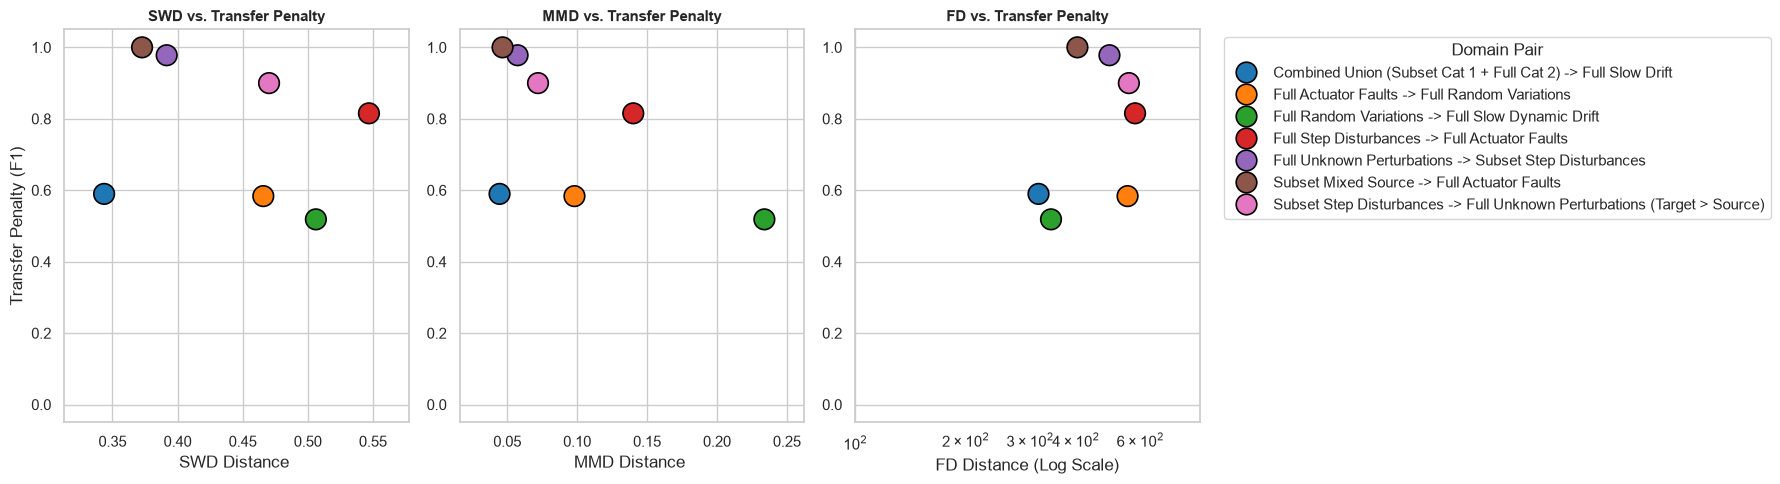

In [ ]:
plot_df = df_mc_summary.groupby('Pair').agg({
    'SWD': 'first',
    'MMD': 'first',
    'FD': 'first',
    'Transfer_Penalty_F1': 'mean'
}).rename(columns={'Transfer_Penalty_F1': 'Average Penalty'}).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ["SWD", "MMD", "FD"]

for i, metric in enumerate(metrics):
    sns.scatterplot(
        data=plot_df, 
        x=metric, 
        y="Average Penalty", 
        hue="Pair",
        palette="tab10", 
        s=220, 
        edgecolor="black", 
        ax=axes[i],
        legend=(i == 2)
    )

    axes[i].set_ylim(-0.05, 1.05)
    
    # Use logarithmic scale for Fréchet Distance (FD) visualization
    if metric == "FD":
        axes[i].set_xscale("log")
        axes[i].set_xlim(left=100, right=plot_df[metric].max() * 1.5)
    else:
        max_dist = plot_df[metric].max()
        min_dist = plot_df[metric].min()
        padding = (max_dist - min_dist) * 0.15 if max_dist > min_dist else 0.1
        axes[i].set_xlim(left=max(0, min_dist - padding), right=max_dist + padding)

    axes[i].set_title(f"{metric} vs. Transfer Penalty", fontsize=11, fontweight="bold")
    axes[i].set_xlabel(f"{metric} Distance {'(Log Scale)' if metric == 'FD' else ''}")
    axes[i].set_ylabel("Transfer Penalty (F1)" if i == 0 else "")
    axes[i].grid(True)

    if i == 2:
        axes[i].legend(title="Domain Pair", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

## 20. Multiclass Diagnostic Shift & Confusion Matrix Analysis

To diagnose specific failure modes under operational domain transfer, we compute and visualize target domain confusion matrices. This highlights which physical mechanism classes remain separable and which suffer from diagnostic misclassification.


Plotting confusion matrix for: Full Step Disturbances -> Full Actuator Faults


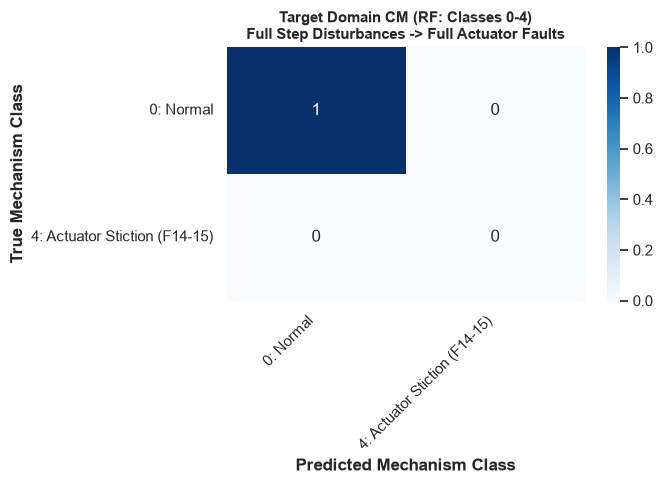

Plotting confusion matrix for: Full Random Variations -> Full Slow Dynamic Drift


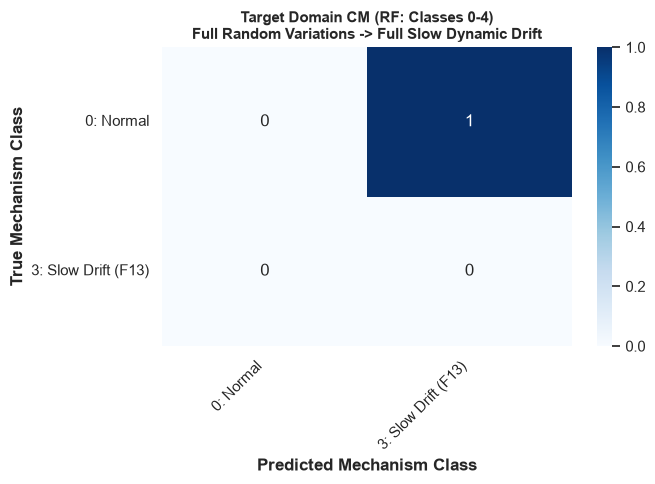

Plotting confusion matrix for: Subset Step Disturbances -> Full Unknown Perturbations (Target > Source)


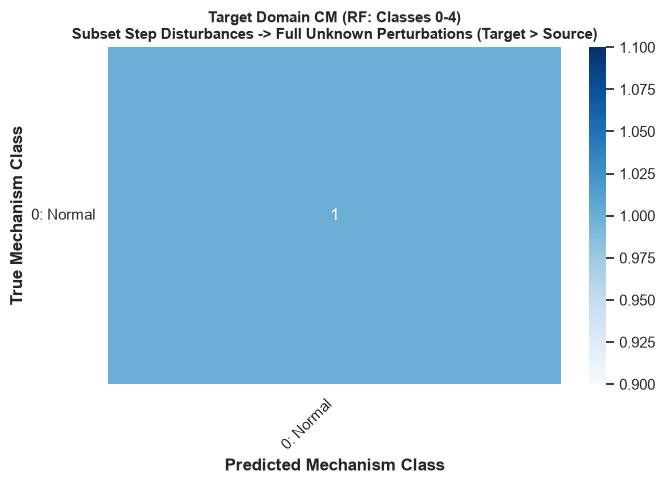

Plotting confusion matrix for: Combined Union (Subset Cat 1 + Full Cat 2) -> Full Slow Drift


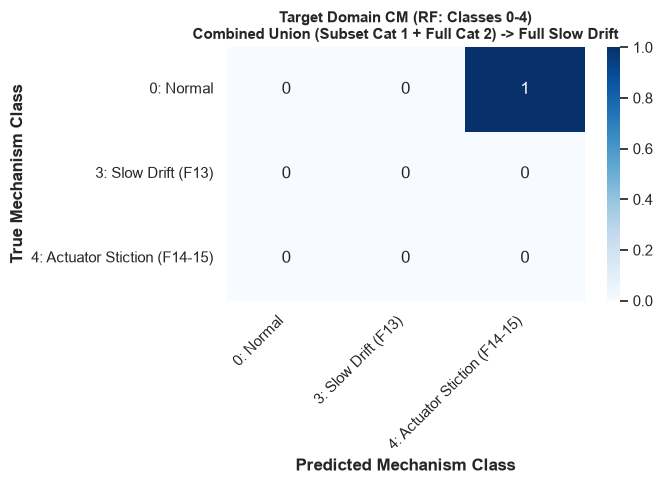

Plotting confusion matrix for: Full Unknown Perturbations -> Subset Step Disturbances


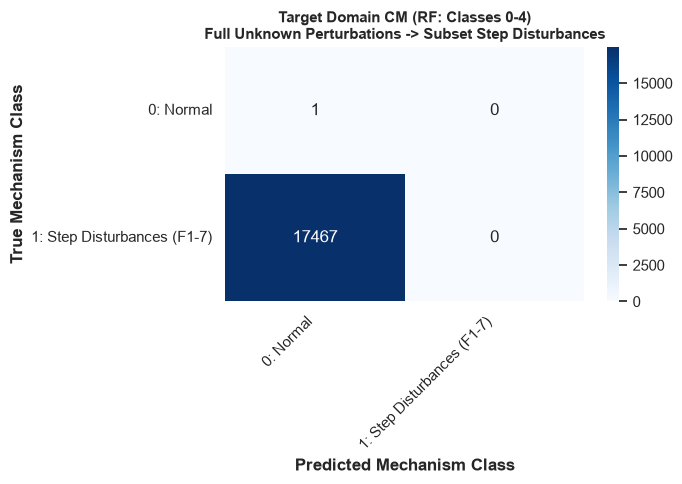

Plotting confusion matrix for: Subset Mixed Source -> Full Actuator Faults


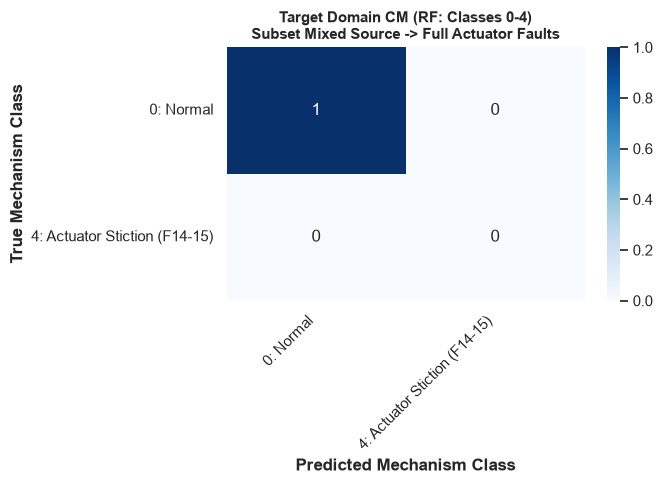

Plotting confusion matrix for: Full Actuator Faults -> Full Random Variations


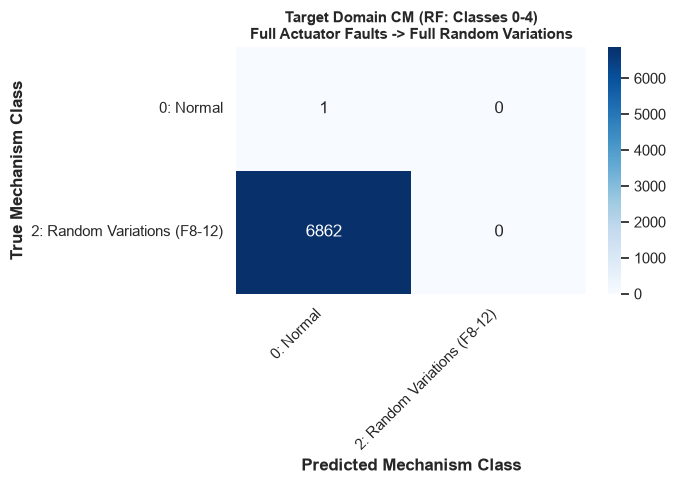

In [ ]:
for pair_name, (cm_data, active_classes) in mc_cms.items():
    print(f"Plotting confusion matrix for: {pair_name}")
    
    # Extract confusion matrix for Random Forest classifier
    rf_cm = cm_data['RF'] if isinstance(cm_data, dict) and 'RF' in cm_data else cm_data[0]
    
    # Filter active mechanism classes for display
    filtered_indices = [i for i, c in enumerate(active_classes) if 0 <= c <= 4]
    if not filtered_indices:
        filtered_indices = list(range(len(active_classes)))
        
    filtered_classes = [active_classes[i] for i in filtered_indices]
    filtered_cm = rf_cm[np.ix_(filtered_indices, filtered_indices)]
    
    class_labels = [MECHANISM_NAMES.get(c, str(c)) for c in filtered_classes]
    
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(filtered_cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels, ax=ax)
    ax.set_title(f'Target Domain CM (RF: Classes 0-4)\n{pair_name}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted Mechanism Class', fontweight='bold')
    ax.set_ylabel('True Mechanism Class', fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

## 21. Executive Takeaways & Comparative Synthesis

This concluding section summarizes key empirical findings across both experimental tracks, providing a comparative matrix between Binary Fault Detection (Part I) and Multiclass Fault Diagnosis (Part II).

| Dimension | Part I: Binary Fault Detection | Part II: Multiclass Fault Diagnosis |
|---|---|---|
| **Task Objective** | Detect *if* an abnormal state is active ($	ext{Normal}=0$ vs $	ext{Fault}=1$) | Identify *which* disturbance mechanism is active ($0 \dots 5$) |
| **Feature Space** | 208 window descriptors ($52 	ext{ variables} 	imes 4 	ext{ statistics}$) | 208 window descriptors ($52 	ext{ variables} 	imes 4 	ext{ statistics}$) |
| **Noise Floor** | $	ext{SWD} pprox 0.048$ (disjoint $F2$ runs) | $	ext{SWD} pprox 0.048$ (disjoint $F2$ runs) |
| **Key Metric** | Binary Transfer F1 & Transfer Penalty | Multiclass Macro F1 & Balanced Accuracy |
